In [2]:
import pandas as pd
import mysql.connector
import numpy as np
import matplotlib.pyplot as plt
import uuid
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
# from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Connecting to database
import mysql.connector

conn = mysql.connector.connect(
    host = '34.123.132.111',
    user = 'root',
    password = 'admin$1',
    database =  'abgrills'
)

cursor = conn.cursor()

# Querying the Data
orders_report_query = '''
        SELECT * FROM orders_report
'''

transaction_report_query = '''
        SELECT * FROM transaction_report
'''

cursor.execute(orders_report_query)
orders_report_data = cursor.fetchall()
orders_report_column_names = [desc[0] for desc in cursor.description]

cursor.execute(transaction_report_query)
transaction_report_data = cursor.fetchall()
transaction_report_column_names = [desc[0] for desc in cursor.description]

conn.close()
cursor.close()

True

## Connecting Orders Report

In [4]:
orders_report = pd.DataFrame(orders_report_data, columns=orders_report_column_names)
orders_report.head().T

,0,1,2,3,4
store_name,AB GRILLS,AB GRILLS,AB GRILLS,AB GRILLS,AB GRILLS
store_location,None,None,None,None,None
country_id,NG,NG,NG,NG,NG
increment_id,R27635318,R27635318,R27635318,R27635318,R27635318
status,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor
state,complete,complete,complete,complete,complete
delivery_method,pickup,pickup,pickup,pickup,pickup
product_name,Indomie Noodles (Small),Indomie Big Pack + Nylon + Cutlery,Sausage,Fried Egg,Add to checkout for delivery within legacy campus
base_currency_code,NGN,NGN,NGN,NGN,NGN
store_currency_code,NGN,NGN,NGN,NGN,NGN


## Connecting Transaction Report

In [5]:
transaction_report = pd.DataFrame(transaction_report_data, columns=transaction_report_column_names)
transaction_report.head().T

,0,1,2,3,4
id,17635318,17635307,17612108,17610561,17610496
store_name,AB GRILLS,AB GRILLS,AB GRILLS,AB GRILLS,AB GRILLS
store_location,None,None,None,None,None
country_id,NG,NG,NG,NG,NG
customer_firstname,Christine,ohuzo,igho,Godfavour,osemwegie
customer_lastname,Christine,kendra,treasure,...,Divine
customer_telephone,2347025318256.0,2349114123031.0,2349053168353.0,2348084421295.0,2348166469000.0
order_status,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor,delivery_confirmed_by_vendor
order_state,complete,complete,complete,complete,complete
increment_id,R27635318,R27635307,R27612108,R27610561,R27610496


## Orders Report

In [6]:
# columns price and base_price are exactly the same. Dropped column base_price
orders_report[orders_report['price'] != orders_report['base_price']]
orders_report.drop('base_price',axis=1,inplace=True)

# columns row_total and base_row_total are exactly the same. Dropped column base_row_total
orders_report[orders_report['row_total'] != orders_report['base_row_total']]
orders_report.drop('base_row_total',axis=1,inplace=True)


# custom_price and base_custom_price only contain 0 values. Dropped columns
orders_report['custom_price'].value_counts()
orders_report['base_custom_price'].value_counts()
orders_report.drop(['custom_price','base_custom_price'],axis=1,inplace=True)

# dropped country_id and base_currency_code columns - No real information there
orders_report.drop(['country_id','base_currency_code'],axis=1,inplace=True)

# coverting created_at datatype to datetime 
orders_report['created_at'] = pd.to_datetime(orders_report['created_at'])
orders_report['created_at'] = orders_report['created_at'].dt.floor('T')

# coverting updated_at datatype to datetime 
orders_report['updated_at'] = pd.to_datetime(orders_report['updated_at'])
orders_report['updated_at'] = orders_report['updated_at'].dt.floor('T')


orders_report['order_year'] = orders_report['created_at'].dt.year
orders_report['order_month'] = orders_report['created_at'].dt.month
orders_report['order_month_name'] = orders_report['created_at'].dt.month_name()


# Renaming Columns
transaction_report.rename(columns={'increment_id':'orders_increment_id'})

,id,store_name,store_location,country_id,customer_firstname,customer_lastname,customer_telephone,order_status,order_state,orders_increment_id,...,order_date,delivery_carrier,delivery_carrier_rate,source,clerk_id,clerk_name,delivery_address,payment_method,amount_ordered,amount_paid
0,17635318,AB GRILLS,None,NG,Christine,Christine,2.347025e+12,delivery_confirmed_by_vendor,complete,R27635318,...,2025-02-16 20:46:12,None,None,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",1946.0,1946.0
1,17635307,AB GRILLS,None,NG,ohuzo,kendra,2.349114e+12,delivery_confirmed_by_vendor,complete,R27635307,...,2025-02-16 20:45:28,None,None,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",2096.0,2096.0
2,17612108,AB GRILLS,None,NG,igho,treasure,2.349053e+12,delivery_confirmed_by_vendor,complete,R27612108,...,2025-02-15 21:19:55,None,None,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",4092.0,4092.0
3,17610561,AB GRILLS,None,NG,Godfavour,...,2.348084e+12,delivery_confirmed_by_vendor,complete,R27610561,...,2025-02-15 20:35:51,None,None,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",1747.0,1747.0
4,17610496,AB GRILLS,None,NG,osemwegie,Divine,2.348166e+12,delivery_confirmed_by_vendor,complete,R27610496,...,2025-02-15 20:33:07,None,None,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",3143.0,3143.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,2505407,AB GRILLS,None,NG,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R12505407,...,2023-03-16 01:33:05,None,None,skg_android,250860.0,Airiede Stephen,"Benson Idahosa University Okah Campus,,NG","transfer,",4500.0,4500.0
19995,2505379,AB GRILLS,None,NG,Abraham,Emopkare,2.347038e+12,delivery_confirmed_by_vendor,complete,R12505379,...,2023-03-16 01:10:49,None,None,skg_android,252049.0,Jane Johnson,"Benson Idahosa University Okah Campus,,NG","cashoncollection_pos,",6000.0,6000.0
19996,2505341,AB GRILLS,None,NG,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R12505341,...,2023-03-16 00:32:48,None,None,skg_android,250860.0,Airiede Stephen,"Benson Idahosa University Okah Campus,,NG","cashoncollection_pos,",1500.0,1500.0
19997,1939166,AB GRILLS,None,NG,Abraham,Emopkare,2.347038e+12,delivery_confirmed_by_vendor,complete,R11939166,...,2023-01-22 16:24:27,None,None,skg_android,252049.0,Jane Johnson,"BIU, Lagacy Campus,,NG","posoncollection,",1500.0,1500.0


## Transaction Report

* transaction orders contains info about customers - their names, address, phone number

* orders contains info about the order itself - what was ordered, total amount paid

In [7]:
# Dropped empty columns
transaction_report.drop(['store_location','delivery_carrier','delivery_carrier_rate'],axis=1,inplace=True)

# columns subtotal and base_subtotal are exactly the same. Dropped column base_subtotal
transaction_report[transaction_report['subtotal'] != transaction_report['base_subtotal']]
transaction_report.drop('base_subtotal',axis=1,inplace=True)

# columns amount_ordered and amount_paid are exactly the same. Dropped column amount_ordered
transaction_report[transaction_report['amount_ordered'] != transaction_report['amount_paid']]
transaction_report.drop('amount_ordered',axis=1,inplace=True)

# columns subtotal and amount_paid are exactly the same. Dropped column subtotal
transaction_report[transaction_report['subtotal'] != transaction_report['amount_paid']]
transaction_report.drop('subtotal',axis=1,inplace=True)

# store_delivery_charge contains only 0 values. Dropped column
transaction_report['store_delivery_charge'].value_counts()
transaction_report.drop('store_delivery_charge',axis=1,inplace=True)

# store_name contains only AB GRILLS. Dropped column
transaction_report['store_name'].value_counts()
transaction_report.drop('store_name',axis=1,inplace=True)

# country_id only contains NG. Dropped column
transaction_report.drop('country_id',axis=1,inplace=True)

# Convert order_date to datetime
transaction_report['order_date'] = pd.to_datetime(transaction_report['order_date'])


# Added Date Time column
transaction_report['transaction_year'] = transaction_report['order_date'].dt.year
transaction_report['transaction_month'] = transaction_report['order_date'].dt.month
transaction_report['transaction_month_name'] = transaction_report['order_date'].dt.month_name()

# Change column name
transaction_report.rename(columns={'increment_id':'transaction_increment_id'})

# change contact number to string
# transaction_report['customer_telephone'] = transaction_report['customer_telephone'].astype('str')





,id,customer_firstname,customer_lastname,customer_telephone,order_status,order_state,transaction_increment_id,delivery_method,order_date,source,clerk_id,clerk_name,delivery_address,payment_method,amount_paid,transaction_year,transaction_month,transaction_month_name
0,17635318,Christine,Christine,2.347025e+12,delivery_confirmed_by_vendor,complete,R27635318,pickup,2025-02-16 20:46:12,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",1946.0,2025,2,February
1,17635307,ohuzo,kendra,2.349114e+12,delivery_confirmed_by_vendor,complete,R27635307,pickup,2025-02-16 20:45:28,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",2096.0,2025,2,February
2,17612108,igho,treasure,2.349053e+12,delivery_confirmed_by_vendor,complete,R27612108,pickup,2025-02-15 21:19:55,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",4092.0,2025,2,February
3,17610561,Godfavour,...,2.348084e+12,delivery_confirmed_by_vendor,complete,R27610561,pickup,2025-02-15 20:35:51,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",1747.0,2025,2,February
4,17610496,osemwegie,Divine,2.348166e+12,delivery_confirmed_by_vendor,complete,R27610496,pickup,2025-02-15 20:33:07,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",3143.0,2025,2,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,2505407,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R12505407,pickup,2023-03-16 01:33:05,skg_android,250860.0,Airiede Stephen,"Benson Idahosa University Okah Campus,,NG","transfer,",4500.0,2023,3,March
19995,2505379,Abraham,Emopkare,2.347038e+12,delivery_confirmed_by_vendor,complete,R12505379,pickup,2023-03-16 01:10:49,skg_android,252049.0,Jane Johnson,"Benson Idahosa University Okah Campus,,NG","cashoncollection_pos,",6000.0,2023,3,March
19996,2505341,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R12505341,pickup,2023-03-16 00:32:48,skg_android,250860.0,Airiede Stephen,"Benson Idahosa University Okah Campus,,NG","cashoncollection_pos,",1500.0,2023,3,March
19997,1939166,Abraham,Emopkare,2.347038e+12,delivery_confirmed_by_vendor,complete,R11939166,pickup,2023-01-22 16:24:27,skg_android,252049.0,Jane Johnson,"BIU, Lagacy Campus,,NG","posoncollection,",1500.0,2023,1,January


In [8]:
len(transaction_report[(transaction_report['customer_telephone'].isna()) & (transaction_report['customer_firstname'].str.lower() != 'guest')])

30

In [9]:
# No unique identifier so added unique customer id column. This unique identifier is based on customer's phone numbers
# Here we assume every customer has a unique phone number.
# Also customer firstname shown as 'Guest' or 'guest' have been given a unique id

# Create a 1 UUID for all "Guest" entries
guest_id = uuid.uuid5(uuid.NAMESPACE_DNS,'guest_id')

def unique_id(row):
    # Check if 'Guest' with missing phone number
    if pd.isna(row['customer_telephone']) and row['customer_firstname'].strip().lower() == 'guest':
        return guest_id # Use the same guest_id for all such cases

    # Check if 'Guest' but has a phone number
    elif row['customer_firstname'].strip().lower() == 'guest':
        return guest_id # Use the same guest_id irrespective of phone number
    
    # Check if customer has a valid phone number
    elif pd.notna(row['customer_telephone']):
        return uuid.uuid5(uuid.NAMESPACE_DNS, str(row['customer_telephone']))

    # If no valid criteria are met
    else:
        return 'nan'
    
transaction_report['customer_id'] = transaction_report.apply(unique_id,axis=1)

In [10]:
## only 22 rows that dont have a phone number and isnt registered as a guest
len(transaction_report[(transaction_report['customer_telephone'].isna())  & (transaction_report['customer_firstname'].str.lower() !='guest')])

30

In [11]:
transaction_report[transaction_report['customer_firstname']=='Guest'].sample(4)

,id,customer_firstname,customer_lastname,customer_telephone,order_status,order_state,increment_id,delivery_method,order_date,source,clerk_id,clerk_name,delivery_address,payment_method,amount_paid,transaction_year,transaction_month,transaction_month_name,customer_id
13919,8032293,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R18032293,dinein,2024-01-23 21:40:02,skg_android,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG","prepaid_pos,",1550.0,2024,1,January,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54
19899,2617246,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R12617246,pickup,2023-03-27 21:24:14,skg_android,250861.0,Efianya Chukwuemeka,"Benson Idahosa University Legacy Campus,,NG","transfer,",2500.0,2023,3,March,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54
19886,2627079,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R12627079,pickup,2023-03-28 19:00:20,skg_android,250859.0,Emmanuel Nwaodiwe,"Benson Idahosa University Legacy Campus,,NG","transfer,",1800.0,2023,3,March,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54
19572,2745318,Guest,Customer,NaN,delivery_confirmed_by_vendor,complete,R12745318,pickup,2023-04-08 20:19:14,skg_android,250860.0,Airiede Stephen,"Benson Idahosa University Legacy Campus,,NG","transfer,",1800.0,2023,4,April,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54


### A. Sales Analysis for Transaction Orders

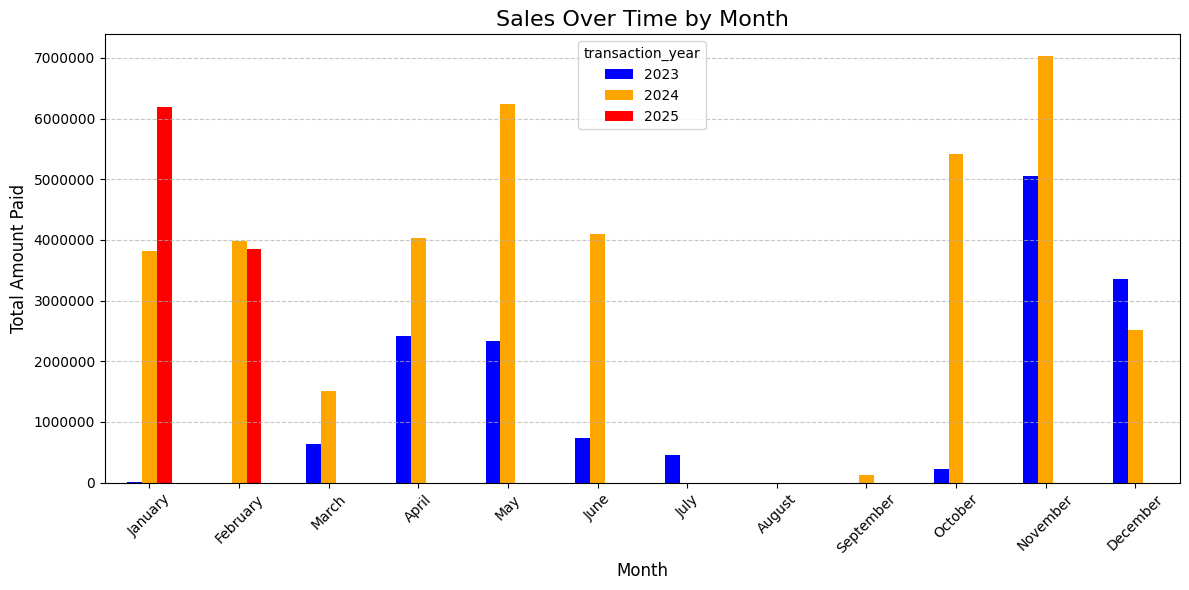

In [12]:
MoM_sales = transaction_report.groupby(['transaction_year','transaction_month_name'])['amount_paid'].sum()

month_order= ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']

# Reindex the DataFrame to ensure months are in proper order
MoM_sales = MoM_sales.unstack(level=0)
MoM_sales = MoM_sales.reindex(labels=month_order)


MoM_sales.plot(kind='bar', figsize=(12, 6), color=['blue', 'orange','red'])

plt.ticklabel_format(style='plain',axis='y')

# Add labels and title for clarity
plt.title('Sales Over Time by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Amount Paid', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

* Over the years, ABGrills have seen consistent growth
* 2024 was more generated more revenue in each month except December than 2023

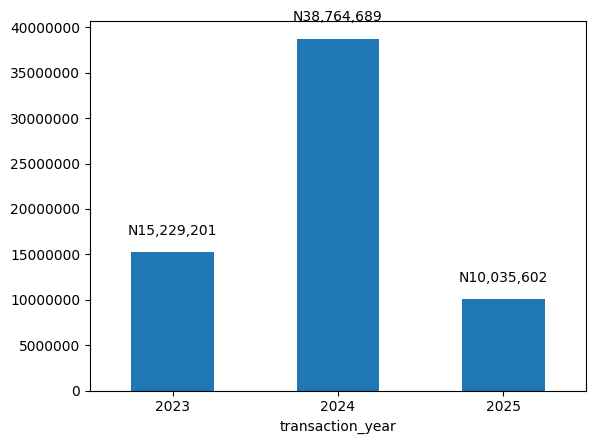

In [13]:
YoY_sales = transaction_report.groupby('transaction_year')['amount_paid'].sum()
YoY_sales.plot(kind='bar')

for i, value in enumerate(YoY_sales):
    plt.text(i,value + 0.05*max(YoY_sales),f'N{value:,.0f}', ha='center', fontsize=10)

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')

plt.show()


### B1. Churn Analysis for Transaction Orders

#### i. recency

In [14]:
import datetime

rfm = pd.DataFrame(transaction_report.groupby('customer_id')['order_date'].max().reset_index())#.rename('recency'))

# the date was 25th Jan 2025
today = pd.to_datetime(datetime.datetime.today())

# new column recency (days) showing days since last purchase
rfm['recency (days)'] = today - rfm['order_date']
rfm['recency (days)'] = rfm['recency (days)'].dt.days
rfm['rfm_year'] = rfm['order_date'].dt.year


In [15]:
rfm

,customer_id,order_date,recency (days),rfm_year
0,00127fba-3dc7-5b66-a30a-26c9b5f84141,2023-04-24 18:45:30,714,2023
1,002f614c-8b51-588b-b4ce-dc179a549dbb,2024-10-04 18:19:12,185,2024
2,00a96437-e53b-5ffc-a329-79d699bd8a83,2023-05-08 21:10:04,700,2023
3,00ce8836-7bb9-50c8-9acd-9077c461d9d6,2025-01-28 21:19:54,69,2025
4,00d8571a-ae6d-5bec-bbdb-b6f0d140d492,2024-11-12 11:34:22,146,2024
...,...,...,...,...
2643,ffd97165-e30f-5076-bf21-d2e2a5a93253,2025-01-18 10:30:27,80,2025
2644,ffdd7e55-460b-582e-8da8-d517461f5f20,2025-01-13 15:06:21,84,2025
2645,fff562b2-b888-5168-9378-3994c265f574,2024-12-11 20:39:08,117,2024
2646,ffff3407-324c-5bad-8ab7-14d5d7aa96ed,2024-05-28 21:22:37,314,2024


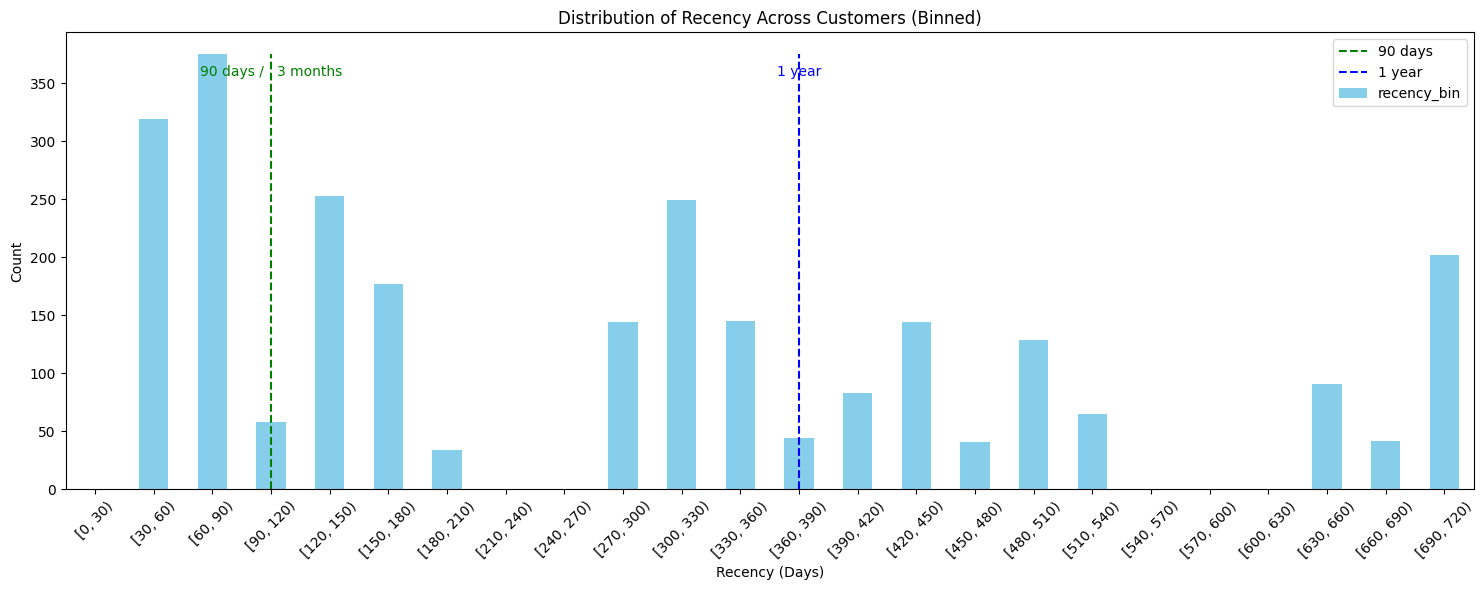

In [16]:
# Group recency into bins of 30 days
rfm['recency_bin'] = pd.cut(rfm['recency (days)'],bins=range(0,750,30),right=False)

# Aggregate the data
recency_bins = rfm.groupby('recency_bin')['recency_bin'].count()

# Plot the grouped data
recency_bins.plot(kind='bar', figsize=(15, 6), color='skyblue')

# Add vertical line for 3 months
plt.vlines(x=3, ymin=0, ymax=recency_bins.max(), colors='green', linestyle='--', label='90 days')
plt.text(3, recency_bins.max() * 0.95, '90 days /   3 months', color='green', fontsize=10, ha='center')

# Add vertical line for 1 year
plt.vlines(x=12, ymin=0, ymax=recency_bins.max(), colors='blue', linestyle='--', label='1 year')
plt.text(12, recency_bins.max() * 0.95, '1 year', color='blue', fontsize=10, ha='center')

           
# Set labels and titles
plt.title('Distribution of Recency Across Customers (Binned)')
plt.xlabel('Recency (Days)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
rfm

,customer_id,order_date,recency (days),rfm_year,recency_bin
0,00127fba-3dc7-5b66-a30a-26c9b5f84141,2023-04-24 18:45:30,714,2023,"[690, 720)"
1,002f614c-8b51-588b-b4ce-dc179a549dbb,2024-10-04 18:19:12,185,2024,"[180, 210)"
2,00a96437-e53b-5ffc-a329-79d699bd8a83,2023-05-08 21:10:04,700,2023,"[690, 720)"
3,00ce8836-7bb9-50c8-9acd-9077c461d9d6,2025-01-28 21:19:54,69,2025,"[60, 90)"
4,00d8571a-ae6d-5bec-bbdb-b6f0d140d492,2024-11-12 11:34:22,146,2024,"[120, 150)"
...,...,...,...,...,...
2643,ffd97165-e30f-5076-bf21-d2e2a5a93253,2025-01-18 10:30:27,80,2025,"[60, 90)"
2644,ffdd7e55-460b-582e-8da8-d517461f5f20,2025-01-13 15:06:21,84,2025,"[60, 90)"
2645,fff562b2-b888-5168-9378-3994c265f574,2024-12-11 20:39:08,117,2024,"[90, 120)"
2646,ffff3407-324c-5bad-8ab7-14d5d7aa96ed,2024-05-28 21:22:37,314,2024,"[300, 330)"


#### i1. Recency per year 2023

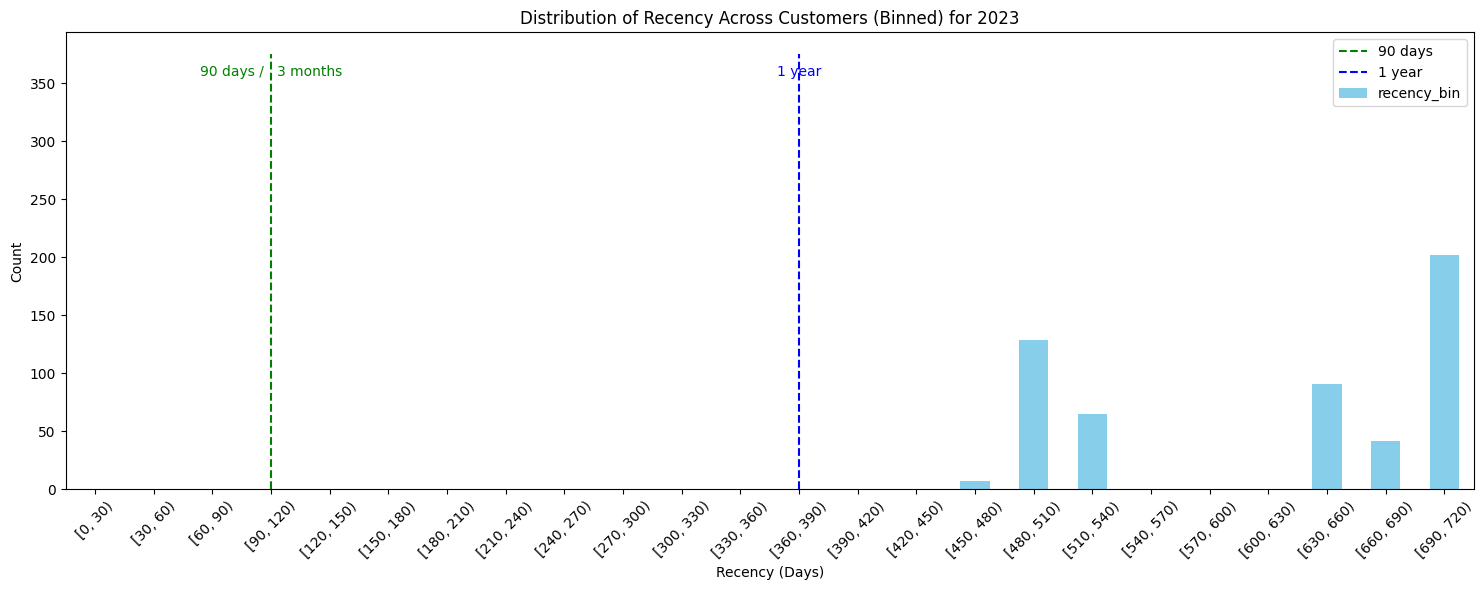

In [18]:
recency2023 = rfm[rfm['rfm_year']==2023]
recency2023 = recency2023.groupby('recency_bin')['recency_bin'].count()

# Plot the grouped data
recency2023.plot(kind='bar', figsize=(15, 6), color='skyblue')

# Add vertical line for 3 months
plt.vlines(x=3, ymin=0, ymax=recency_bins.max(), colors='green', linestyle='--', label='90 days')
plt.text(3, recency_bins.max() * 0.95, '90 days /   3 months', color='green', fontsize=10, ha='center')

# Add vertical line for 1 year
plt.vlines(x=12, ymin=0, ymax=recency_bins.max(), colors='blue', linestyle='--', label='1 year')
plt.text(12, recency_bins.max() * 0.95, '1 year', color='blue', fontsize=10, ha='center')

           
# Set labels and titles
plt.title('Distribution of Recency Across Customers (Binned) for 2023')
plt.xlabel('Recency (Days)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### i2. Recency per year 2024

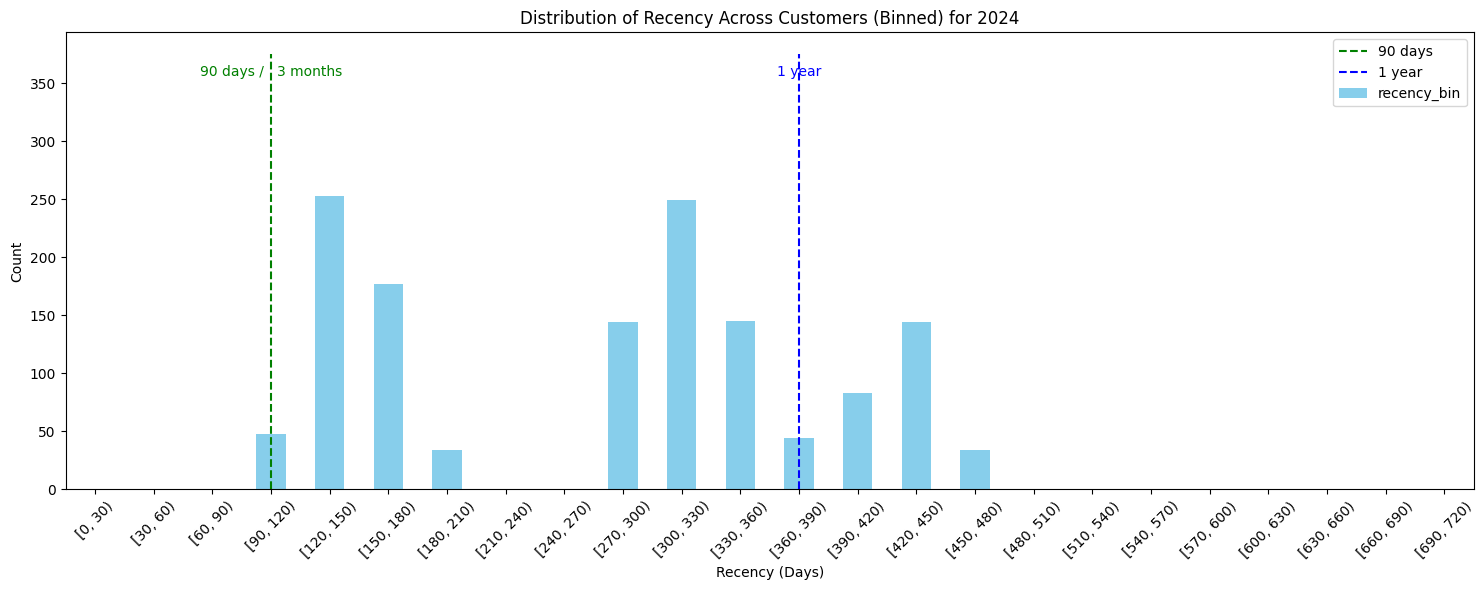

In [19]:
recency2024 = rfm[rfm['rfm_year']==2024]
recency2024 = recency2024.groupby('recency_bin')['recency_bin'].count()

# Plot the grouped data
recency2024.plot(kind='bar', figsize=(15, 6), color='skyblue')

# Add vertical line for 3 months
plt.vlines(x=3, ymin=0, ymax=recency_bins.max(), colors='green', linestyle='--', label='90 days')
plt.text(3, recency_bins.max() * 0.95, '90 days /   3 months', color='green', fontsize=10, ha='center')

# Add vertical line for 1 year
plt.vlines(x=12, ymin=0, ymax=recency_bins.max(), colors='blue', linestyle='--', label='1 year')
plt.text(12, recency_bins.max() * 0.95, '1 year', color='blue', fontsize=10, ha='center')

           
# Set labels and titles
plt.title('Distribution of Recency Across Customers (Binned) for 2024')
plt.xlabel('Recency (Days)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### i3. Recency per year 2025

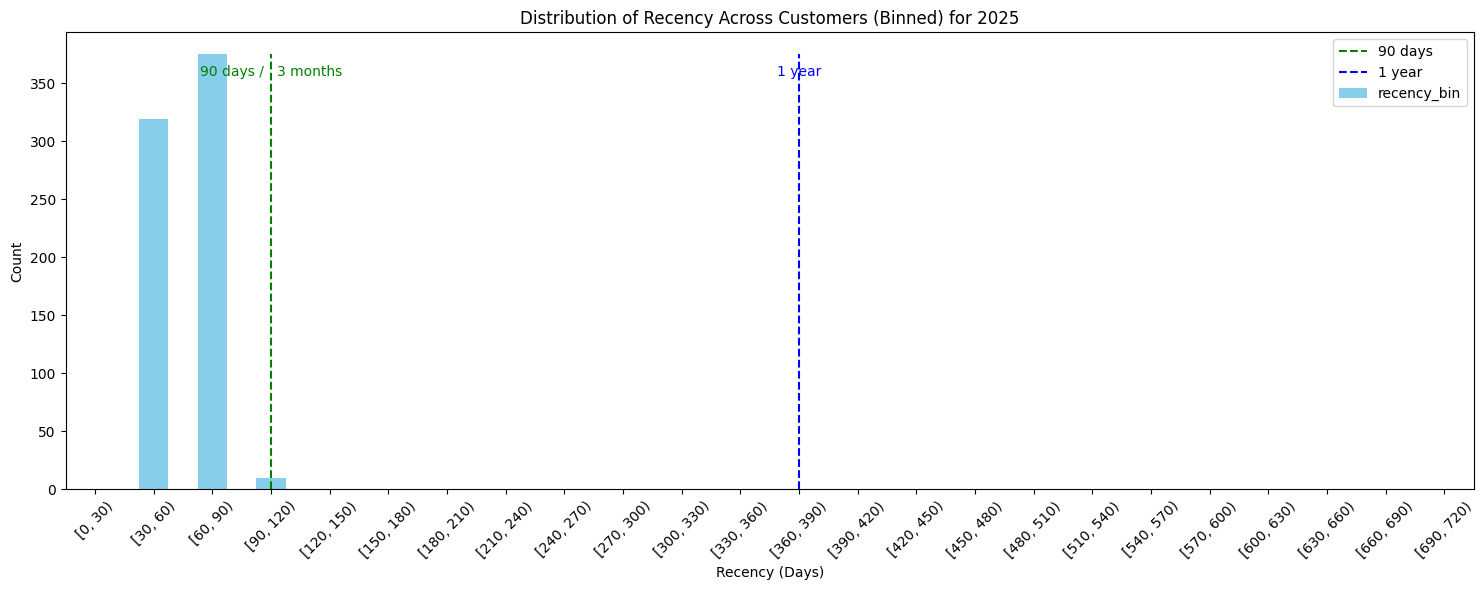

In [20]:
recency2025 = rfm[rfm['rfm_year']==2025]
recency2025 = recency2025.groupby('recency_bin')['recency_bin'].count()

# Plot the grouped data
recency2025.plot(kind='bar', figsize=(15, 6), color='skyblue')

# Add vertical line for 3 months
plt.vlines(x=3, ymin=0, ymax=recency_bins.max(), colors='green', linestyle='--', label='90 days')
plt.text(3, recency_bins.max() * 0.95, '90 days /   3 months', color='green', fontsize=10, ha='center')

# Add vertical line for 1 year
plt.vlines(x=12, ymin=0, ymax=recency_bins.max(), colors='blue', linestyle='--', label='1 year')
plt.text(12, recency_bins.max() * 0.95, '1 year', color='blue', fontsize=10, ha='center')

           
# Set labels and titles
plt.title('Distribution of Recency Across Customers (Binned) for 2025')
plt.xlabel('Recency (Days)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### ii. frequency

In [21]:
freq = pd.DataFrame(transaction_report.groupby('customer_id')['order_date'].count().reset_index().rename(columns={'order_date':'frequency'}))


In [22]:
freq['frequency'].max()

np.int64(682)

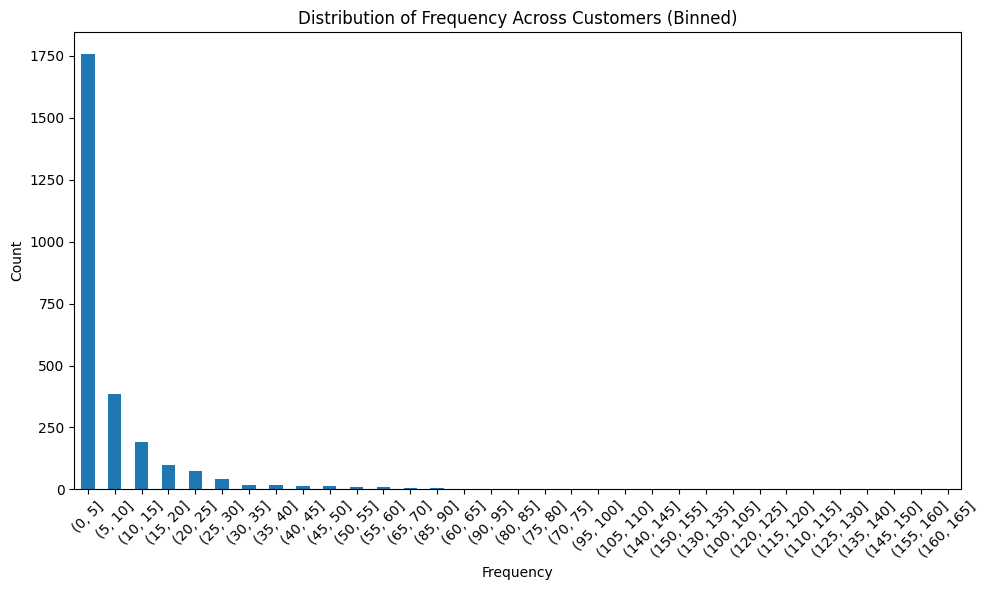

In [23]:
rfm = pd.merge(rfm,freq,on='customer_id',how='inner')

# Group recency into bins of 30 days
rfm['frequency_bin'] = pd.cut(rfm['frequency'],bins=range(0,170,5))


rfm['frequency_bin'].value_counts().plot(kind='bar',figsize=(10,6))
# Set labels and titles
plt.title('Distribution of Frequency Across Customers (Binned)')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
rfm[rfm['customer_id']=='nan']

,customer_id,order_date,recency (days),rfm_year,recency_bin,frequency,frequency_bin
2647,nan,2025-02-10 15:25:08,56,2025,"[30, 60)",30,"(25, 30]"


#### iii. Monetary

In [25]:
monetary = transaction_report.groupby('customer_id')['amount_paid'].sum().reset_index().rename(columns={'amount_paid':'total_amount'})
rfm = pd.merge(rfm,monetary,on='customer_id',how='left')

#### iv. Creating a score for each element of RFM

In [26]:
rfm.loc[:,'recency_score'] = pd.qcut(rfm['recency (days)'],5,labels=[5,4,3,2,1])
rfm.loc[:,'frequency_score'] = pd.qcut(rfm['frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm.loc[:,'monetary_score'] = pd.qcut(rfm['total_amount'],5,labels=[1,2,3,4,5])

rfm['rfm_score'] = round(((rfm['recency_score'].astype(int) + rfm['frequency_score'].astype(int) + rfm['monetary_score'].astype(int))/3),1)

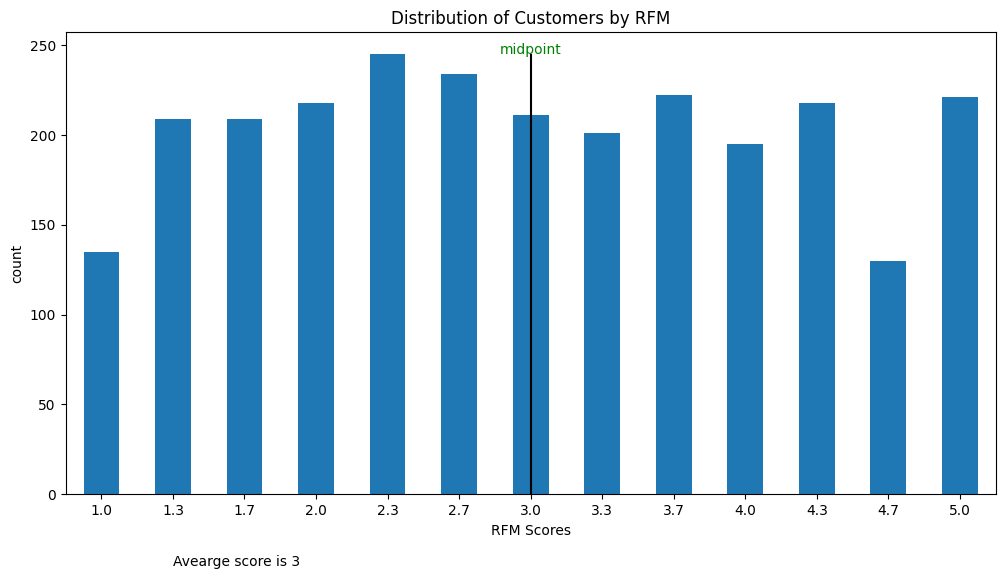

In [27]:
rfm['rfm_score'].value_counts().sort_index().plot(kind='bar',figsize=(12,6))
plt.vlines(x=6,ymin=0,ymax=rfm['rfm_score'].value_counts().max(),linestyles='-',colors='black')
plt.text(x=6, y=rfm['rfm_score'].value_counts().max(),s='midpoint', color='green', ha='center')

mean_score = rfm['rfm_score'].mean()

plt.title('Distribution of Customers by RFM')
plt.ylabel('count')
plt.xlabel('RFM Scores')
plt.xticks(rotation=0)

plt.text(1,-40, f'Avearge score is {mean_score:.0f}')
plt.show()

#### iv.a) RFM score distribution for 2023

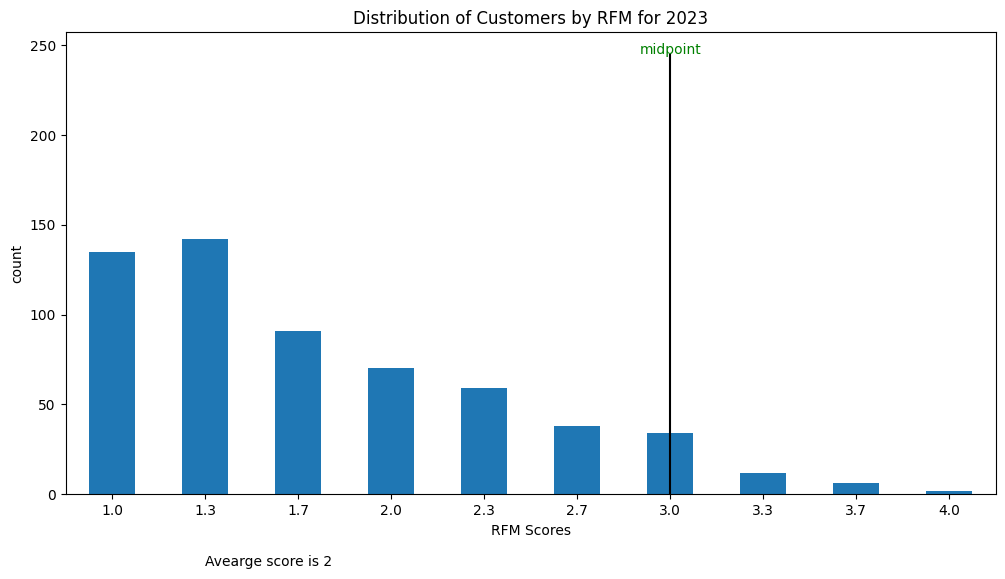

In [28]:
rfm2023 = rfm[rfm['rfm_year']==2023]

rfm2023['rfm_score'].value_counts().sort_index().plot(kind='bar',figsize=(12,6))
plt.vlines(x=6,ymin=0,ymax=rfm['rfm_score'].value_counts().max(),linestyles='-',colors='black')
plt.text(x=6, y=rfm['rfm_score'].value_counts().max(),s='midpoint', color='green', ha='center')

mean_score = rfm2023['rfm_score'].mean()

plt.title('Distribution of Customers by RFM for 2023')
plt.ylabel('count')
plt.xlabel('RFM Scores')
plt.xticks(rotation=0)

plt.text(1,-40, f'Avearge score is {mean_score:.0f}')
plt.show()

#### iv.b) RFM score distribution for 2024

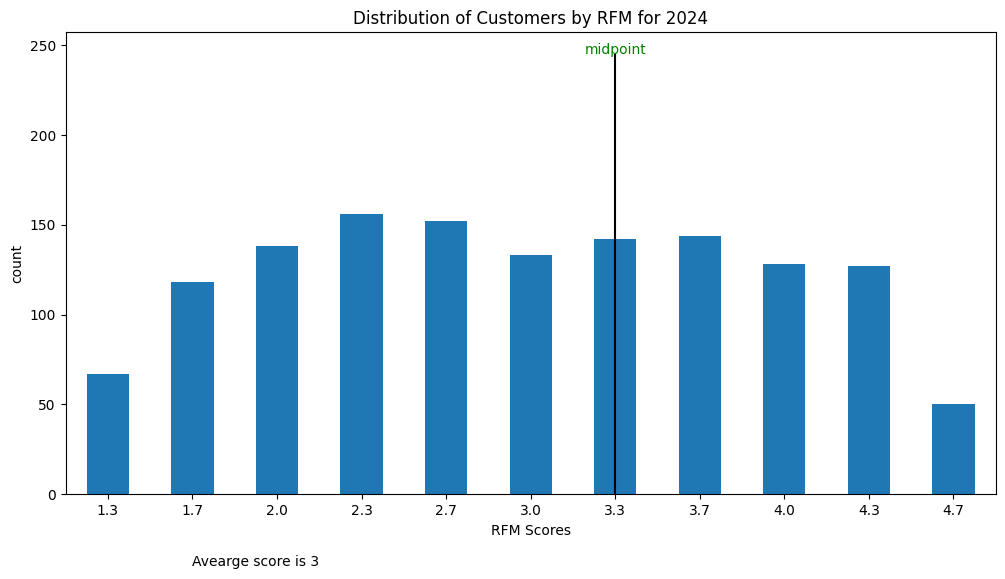

In [29]:
rfm_score2024 = rfm[rfm['rfm_year']==2024]

rfm_score2024['rfm_score'].value_counts().sort_index().plot(kind='bar',figsize=(12,6))
plt.vlines(x=6,ymin=0,ymax=rfm['rfm_score'].value_counts().max(),linestyles='-',colors='black')
plt.text(x=6, y=rfm['rfm_score'].value_counts().max(),s='midpoint', color='green', ha='center')

mean_score = rfm_score2024['rfm_score'].mean()

plt.title('Distribution of Customers by RFM for 2024')
plt.ylabel('count')
plt.xlabel('RFM Scores')
plt.xticks(rotation=0)

plt.text(1,-40, f'Avearge score is {mean_score:.0f}')
plt.show()

#### iv.c) RFM score distribution for 2025

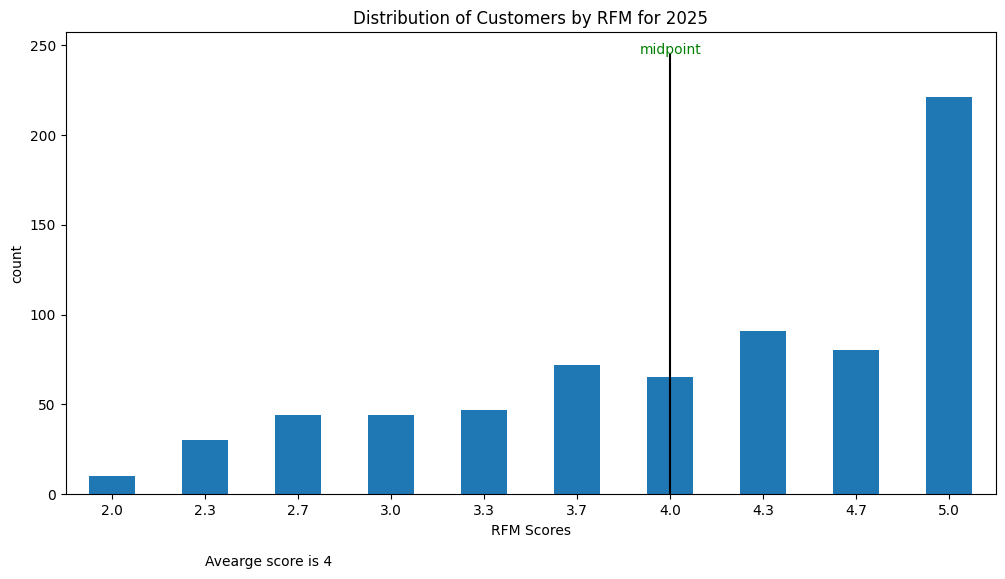

In [30]:
rfm_score2025 = rfm[rfm['rfm_year']==2025]

rfm_score2025['rfm_score'].value_counts().sort_index().plot(kind='bar',figsize=(12,6))
plt.vlines(x=6,ymin=0,ymax=rfm['rfm_score'].value_counts().max(),linestyles='-',colors='black')
plt.text(x=6, y=rfm['rfm_score'].value_counts().max(),s='midpoint', color='green', ha='center')

mean_score = rfm_score2025['rfm_score'].mean()

plt.title('Distribution of Customers by RFM for 2025')
plt.ylabel('count')
plt.xlabel('RFM Scores')
plt.xticks(rotation=0)

plt.text(1,-40, f'Avearge score is {mean_score:.0f}')
plt.show()

### B2. Segementation

#### i. Normalise with Standar scaler

In [31]:
rfm = rfm[rfm['customer_id']!='nan']

In [32]:
new_rfm = rfm.drop('customer_id',axis=1)
new_rfm['year'] = new_rfm['order_date'].dt.year
new_rfm['month'] = new_rfm['order_date'].dt.month
new_rfm['month_name'] = new_rfm['order_date'].dt.month_name


In [33]:
new_rfm = rfm.drop(['order_date','customer_id','frequency_bin','recency_bin'],axis=1)


In [34]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
standardised_rfm = pd.DataFrame(scale.fit_transform(X=new_rfm),columns=new_rfm.columns)

#### ii. Use k-means to segment

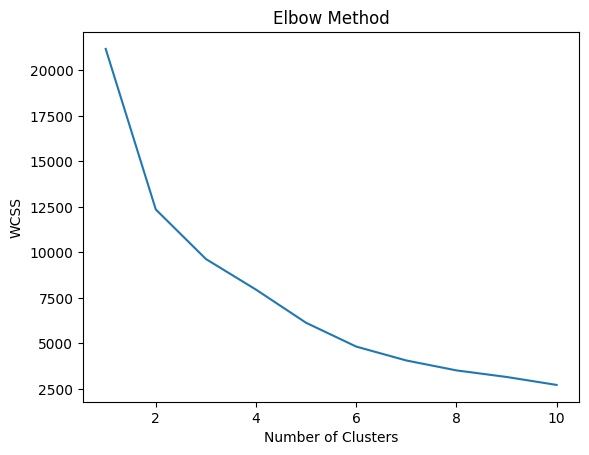

In [35]:
from sklearn.cluster import KMeans

wcss = [] # within-cluster sum of squares

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=100,n_init=5,random_state=100)
    kmeans = kmeans.fit(standardised_rfm)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

The optimal number is 2 because it is the point before the curve starts to flatten. That means, adding an extra cluster marginally reduces the WCSS and very little diminishing returns

In [36]:
k = 2

kmeans = KMeans(n_clusters=k,init='k-means++',max_iter=100,n_init=5,random_state=100)
new_rfm['cluster'] = kmeans.fit_predict(standardised_rfm)
new_rfm


,recency (days),rfm_year,frequency,total_amount,recency_score,frequency_score,monetary_score,rfm_score,cluster
0,714,2023,1,6000.0,1,1,2,1.3,1
1,185,2024,2,4746.0,3,2,2,2.3,1
2,700,2023,1,1700.0,1,1,1,1.0,1
3,69,2025,20,50473.0,5,5,5,5.0,0
4,146,2024,3,12140.0,4,3,3,3.3,0
...,...,...,...,...,...,...,...,...,...
2642,408,2024,1,2649.0,2,2,1,1.7,1
2643,80,2025,39,66815.0,4,5,5,4.7,0
2644,84,2025,8,47378.0,4,4,5,4.3,0
2645,117,2024,15,50771.0,4,5,5,4.7,0


In [37]:
# adding cluster column to rfm dataframe
rfm = pd.merge(rfm,new_rfm['cluster'],how='left',left_index=True,right_index=True)

In [38]:
#adding cluster to main df - transaction report
# NOTE: THIS INNER JOIN MEANS Cutsomer_id == 'nan' is removed because its not found in rfm table
transaction_report = pd.merge(transaction_report,rfm[['customer_id','cluster']],on='customer_id',how='inner')


#### Defining Churn

* Churn in this case will be customers that havent purchased an item as long as 90 days. (Recency (days) more than 90)

In [39]:
# Added a churn column - true if recency > 90
rfm['churn'] = rfm['recency (days)'].map(lambda x: False if x < 90 else True)

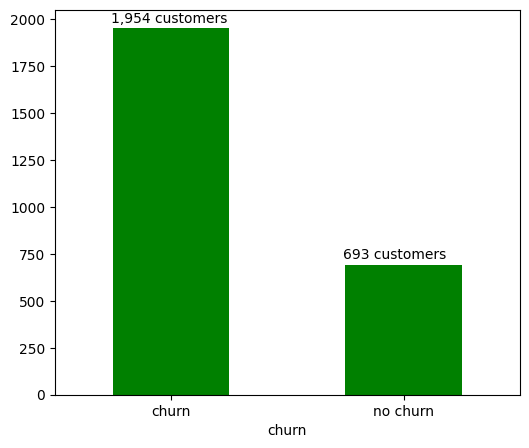

In [40]:
churn_distribution = rfm['churn'].value_counts()
plot = churn_distribution.plot(kind='bar',color='green',figsize=(6,5))
plot.set_xticklabels(['churn','no churn'])

for i,value in enumerate(churn_distribution.values):
    plt.text(i-0.26,value+30,s=f'{value:,} customers')

plt.xticks(rotation=0)
plt.show()

Checking churn distribution based on each delivery method

In [41]:
#creating df to check most frequent delivery method for each customer
most_frq_delivery = transaction_report.groupby('customer_id')['delivery_method'].agg(lambda x: x.mode()[0]).reset_index()

# joing most_frq_delivery df with rfm
rfm = pd.merge(left=rfm,right=most_frq_delivery,on='customer_id',how='left')

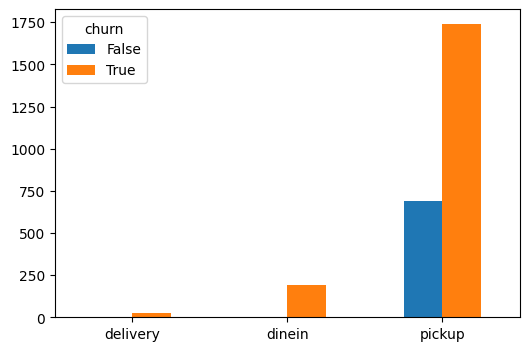

In [42]:
delivery_churn = rfm.groupby(['delivery_method','churn'])['delivery_method'].count().unstack().reset_index()
# delivery_churn

ax = delivery_churn.plot(kind='bar',figsize=(6,4)).set_xticklabels(['delivery','dinein','pickup'],rotation=0)


plt.show()

Year of Year Change in Churn

In [43]:
rfm['rfm_year'] = rfm['order_date'].dt.year

In [44]:
yoy_churn = pd.DataFrame(rfm.groupby('rfm_year')['churn'].sum().reset_index())
yoy_churn['percent_change'] = round((yoy_churn['churn'].pct_change()*100),2)
yoy_churn

,rfm_year,churn,percent_change
0,2023,589,NaN
1,2024,1355,130.05
2,2025,10,-99.26


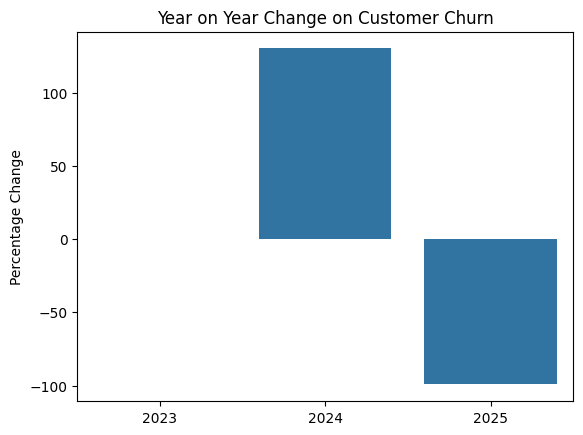

In [45]:
sns.barplot(data=yoy_churn,x='rfm_year',y='percent_change')


plt.title('Year on Year Change on Customer Churn')
plt.ylabel('Percentage Change')
plt.xlabel('')
plt.show()

In [46]:
rfm['rfm_month'] = rfm['order_date'].dt.month
rfm['rfm_month_name'] = rfm['order_date'].dt.month_name()


Month on Month Churn change

In [47]:
mom_churn = pd.DataFrame(rfm.groupby(['rfm_year','rfm_month','rfm_month_name'])['churn'].count().reset_index())
mom_churn['mom_percent_change'] = mom_churn['churn'].pct_change()*100


Month on Month Percentage Change in churn for 2023

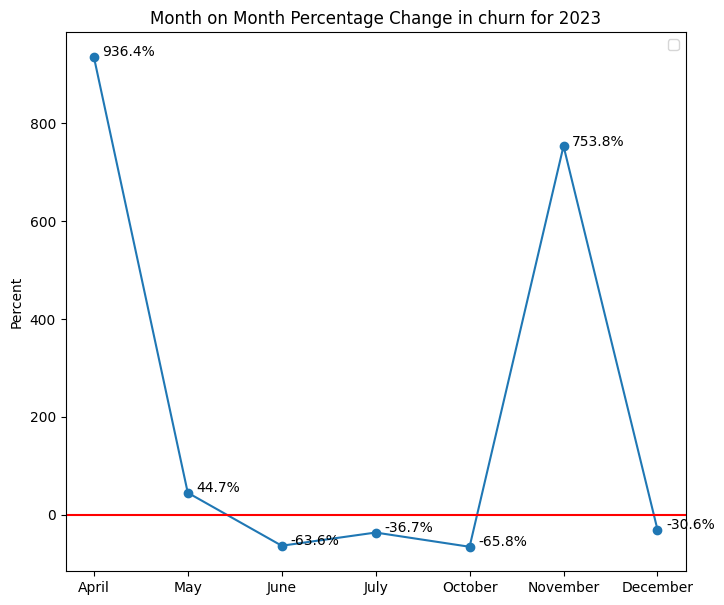

In [48]:
mom_churn2023 = mom_churn[mom_churn['rfm_year']==2023][['rfm_month_name','mom_percent_change']]
mom_churn2023.plot(kind='line',marker='o',figsize=(8,7)).set_xticklabels(labels=mom_churn2023['rfm_month_name'])


# to label each value on the visual
for i,value in enumerate(mom_churn2023['mom_percent_change'] ):
    plt.text(i+0.09,value+1,s=f'{round(value,1)}%')

plt.axhline(y=0,color='red')


plt.title('Month on Month Percentage Change in churn for 2023')
plt.ylabel('Percent')
plt.xlabel('')
plt.legend('')
plt.show()

Month on Month Percentage Change in churn for 2024

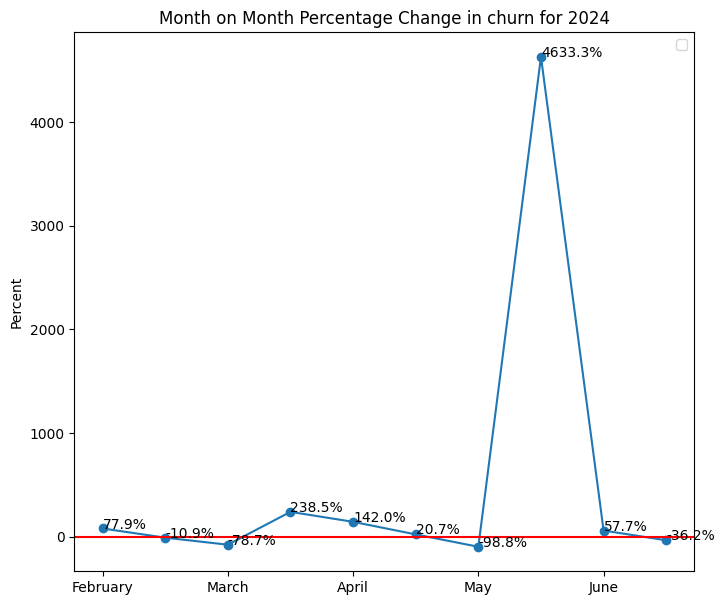

In [49]:
mom_churn2024 = mom_churn[mom_churn['rfm_year']==2024][['rfm_month_name','mom_percent_change']]
mom_churn2024.plot(kind='line',marker='o',figsize=(8,7)).set_xticklabels(labels=mom_churn2024['rfm_month_name'])


# to label each value on the visual
for i,value in enumerate(mom_churn2024['mom_percent_change'] ):
    plt.text(i+8,value,s=f'{round(value,1)}%')

plt.axhline(y=0,color='red')


plt.title('Month on Month Percentage Change in churn for 2024')
plt.ylabel('Percent')
plt.xlabel('')
plt.legend('')
plt.show()

Dont have enough data for 2025

In [50]:
len(transaction_report)

19969

In [51]:
orders_report.head(2)

,store_name,store_location,increment_id,status,state,delivery_method,product_name,store_currency_code,price,qty,row_total,payment_method,created_at,updated_at,order_item_integrator_option,order_year,order_month,order_month_name
0,AB GRILLS,None,R27635318,delivery_confirmed_by_vendor,complete,pickup,Indomie Noodles (Small),NGN,599.0,1.0,599.0,prepaid_pos,2025-02-16 20:46:00+00:00,2025-02-16 19:47:00+00:00,None,2025,2,February
1,AB GRILLS,None,R27635318,delivery_confirmed_by_vendor,complete,pickup,Indomie Big Pack + Nylon + Cutlery,NGN,249.0,1.0,249.0,prepaid_pos,2025-02-16 20:46:00+00:00,2025-02-16 19:47:00+00:00,None,2025,2,February


### Merged both Tables

In [52]:
result = pd.merge(
    left=transaction_report,
    right=orders_report,
    on='increment_id',
    how='inner'
)


# cleaning
result.drop('delivery_method_x',axis=1,inplace=True)
result.drop('payment_method_y',axis=1,inplace=True)
result.drop('order_item_integrator_option',axis=1,inplace=True)
result.drop('store_currency_code',axis=1,inplace=True)
result.drop(['created_at','updated_at'],axis=1,inplace=True)
result.drop('delivery_method_y',axis=1,inplace=True)
result.drop('payment_method_x',axis=1,inplace=True)
result.drop('store_location',axis=1,inplace=True)
result.drop(['transaction_year','transaction_month','transaction_month_name'],axis=1,inplace=True)
result.drop('store_name',axis=1,inplace=True)
result.drop('source',axis=1,inplace=True)
result.drop('status',axis=1,inplace=True)
result.drop('order_status',axis=1,inplace=True)
result.rename(columns={'amount_paid':'total_amount_paid_for_order'},inplace=True)

In [53]:
# to merge recency and frequency to result - result df already has monetary(total_amount_paid_for_order)
to_merge_rfm_to_result = rfm[['customer_id','recency (days)','frequency']]

result = pd.merge(left=result,right=to_merge_rfm_to_result,on='customer_id',how='inner')

In [54]:
model_dataset = pd.DataFrame(result.groupby(['customer_id','increment_id'])['total_amount_paid_for_order'].max()).reset_index()
model_dataset = pd.DataFrame(model_dataset.groupby('customer_id')['total_amount_paid_for_order'].sum()).reset_index()

max_cluster = result.groupby('customer_id')['cluster'].max()
model_dataset = model_dataset.merge(max_cluster, on='customer_id', suffixes=('', '_max'))

max_qty = pd.DataFrame(result.groupby(['customer_id','increment_id'])['qty'].sum()).reset_index()
max_qty = pd.DataFrame(max_qty.groupby('customer_id')['qty'].sum()).reset_index()
model_dataset = pd.merge(model_dataset,max_qty,on='customer_id')

max_recency = pd.DataFrame(result.groupby('customer_id')['recency (days)'].max()).reset_index()
model_dataset = pd.merge(model_dataset,max_recency,on='customer_id')

max_frequency = pd.DataFrame(result.groupby('customer_id')['frequency'].max()).reset_index()
model_dataset = pd.merge(model_dataset,max_frequency,on='customer_id')


max_churn = rfm.groupby('customer_id',as_index=False)['churn'].max()
mapper = {True:1,False:0}
max_churn['churn'] = max_churn['churn'].map(mapper)
model_dataset = pd.merge(model_dataset,max_churn,on='customer_id')

model_dataset.drop('customer_id',axis=1,inplace=True)

model_dataset

,total_amount_paid_for_order,cluster,qty,recency (days),frequency,churn
0,6000.0,1,2.0,714,1,1
1,4746.0,1,4.0,185,2,1
2,1700.0,1,1.0,700,1,1
3,50473.0,0,117.0,69,20,0
4,12140.0,0,19.0,146,3,1
...,...,...,...,...,...,...
2642,2649.0,1,1.0,408,1,1
2643,66815.0,0,87.0,80,39,0
2644,47378.0,0,78.0,84,8,0
2645,50771.0,0,73.0,117,15,1


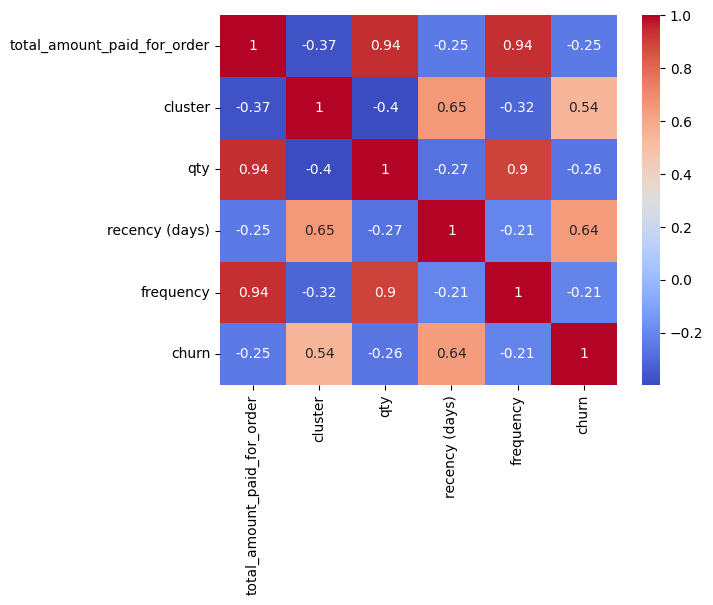

In [55]:
model_corr = model_dataset.corr()
sns.heatmap(model_corr,cmap='coolwarm',annot=True)
plt.show()

### Churn Prediction for Transaction Orders

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

#### Modelling

In [57]:
target = model_dataset['churn']
features = model_dataset.drop('churn',axis=1)

X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.3,random_state=233)

rc = RandomForestClassifier(n_estimators=50,oob_score=True)
rc.fit(X_train,y_train)

train_prediction = rc.predict(X_train)
test_prediction = rc.predict(X_test)


In [58]:
from sklearn.metrics import *
print(accuracy_score(train_prediction,y_train))
print(confusion_matrix(train_prediction,y_train))
print('------------------------------')
print(accuracy_score(test_prediction,y_test))
print(confusion_matrix(test_prediction,y_test))



1.0
[[ 469    0]
 [   0 1383]]
------------------------------
1.0
[[224   0]
 [  0 571]]


In [59]:
pd.Series(index=rc.feature_names_in_,data=rc.feature_importances_).sort_values(ascending=False).reset_index().rename(columns={0:'value'})

,index,value
0,recency (days),0.831577
1,cluster,0.107482
2,total_amount_paid_for_order,0.031198
3,qty,0.022298
4,frequency,0.007445


## Time Series Sales Prediction

In [60]:
result.head()

,id,customer_firstname,customer_lastname,customer_telephone,order_state,increment_id,order_date,clerk_id,clerk_name,delivery_address,...,state,product_name,price,qty,row_total,order_year,order_month,order_month_name,recency (days),frequency
0,17635318,Christine,Christine,2.347025e+12,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",...,complete,Indomie Noodles (Small),599.0,1.0,599.0,2025,2,February,50,50
1,17635318,Christine,Christine,2.347025e+12,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",...,complete,Indomie Big Pack + Nylon + Cutlery,249.0,1.0,249.0,2025,2,February,50,50
2,17635318,Christine,Christine,2.347025e+12,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",...,complete,Sausage,399.0,1.0,399.0,2025,2,February,50,50
3,17635318,Christine,Christine,2.347025e+12,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",...,complete,Fried Egg,449.0,1.0,449.0,2025,2,February,50,50
4,17635318,Christine,Christine,2.347025e+12,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",...,complete,Add to checkout for delivery within legacy campus,250.0,1.0,250.0,2025,2,February,50,50


In [61]:
result.iloc[:,4:]

,order_state,increment_id,order_date,clerk_id,clerk_name,delivery_address,total_amount_paid_for_order,customer_id,cluster,state,product_name,price,qty,row_total,order_year,order_month,order_month_name,recency (days),frequency
0,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",1946.0,ba1aeb9b-7c6d-5f52-b7d7-8b94f8347b84,0,complete,Indomie Noodles (Small),599.0,1.0,599.0,2025,2,February,50,50
1,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",1946.0,ba1aeb9b-7c6d-5f52-b7d7-8b94f8347b84,0,complete,Indomie Big Pack + Nylon + Cutlery,249.0,1.0,249.0,2025,2,February,50,50
2,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",1946.0,ba1aeb9b-7c6d-5f52-b7d7-8b94f8347b84,0,complete,Sausage,399.0,1.0,399.0,2025,2,February,50,50
3,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",1946.0,ba1aeb9b-7c6d-5f52-b7d7-8b94f8347b84,0,complete,Fried Egg,449.0,1.0,449.0,2025,2,February,50,50
4,complete,R27635318,2025-02-16 20:46:12,267702.0,Amiegbereta Marvellous,"Benson Idahosa University Legacy Campus,,NG",1946.0,ba1aeb9b-7c6d-5f52-b7d7-8b94f8347b84,0,complete,Add to checkout for delivery within legacy campus,250.0,1.0,250.0,2025,2,February,50,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62966,complete,R11939143,2023-01-22 16:19:31,252049.0,Jane Johnson,"Dummy street,,NG",4700.0,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54,0,complete,Sharwama,0.0,1.0,0.0,2023,1,January,52,682
62967,complete,R11939143,2023-01-22 16:19:31,252049.0,Jane Johnson,"Dummy street,,NG",4700.0,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54,0,complete,Milkshake,1500.0,1.0,1500.0,2023,1,January,52,682
62968,complete,R11939143,2023-01-22 16:19:31,252049.0,Jane Johnson,"Dummy street,,NG",4700.0,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54,0,complete,Chapman,1500.0,1.0,1500.0,2023,1,January,52,682
62969,complete,R11939143,2023-01-22 16:19:31,252049.0,Jane Johnson,"Dummy street,,NG",4700.0,74a0461f-f8af-5d9f-b5e1-1e1a784e2a54,0,complete,"Turkey, Sweet Potatoes & Sauce",1500.0,1.0,1500.0,2023,1,January,52,682


In [62]:
date_only = result['order_date'].dt.date

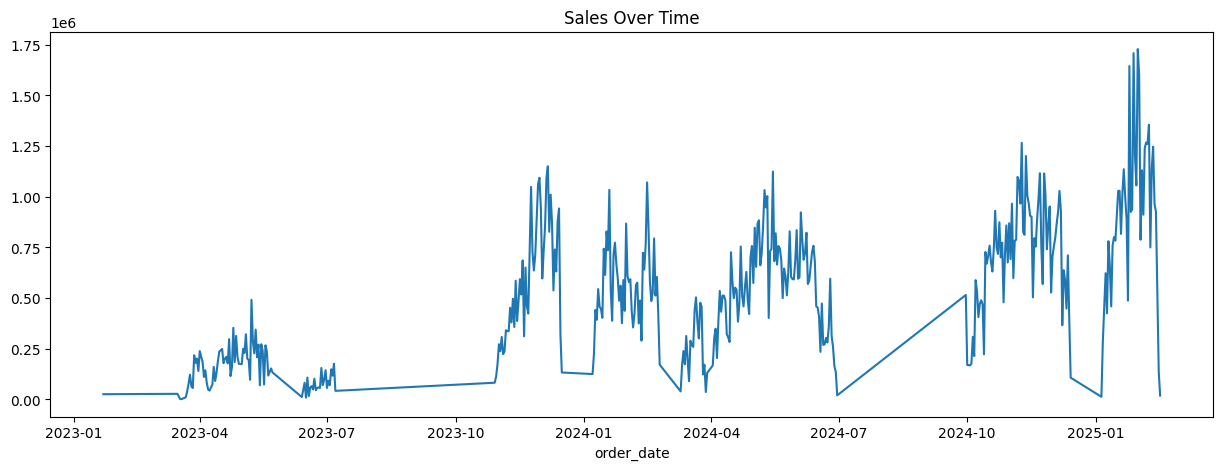

In [63]:
sales_over_time = result.groupby(date_only)['total_amount_paid_for_order'].sum()

sales_over_time.plot(style='-',figsize=(15,5),title='Sales Over Time')

plt.show()

### Feature Engineering

In [64]:
xgb_data = pd.DataFrame(result['order_date'])
xgb_data.rename(columns={'order_date':'order_date_time'},inplace=True)


#### new from this morning

In [65]:
date = result['order_date'].dt.date

xgb_data = pd.DataFrame(result.groupby(date)['row_total'].sum())
xgb_data.rename(columns={'row_total':'total_sales'},inplace=True)


# average qty per day
avg_order = result.groupby(date)['qty'].mean().rename('average_qty')
xgb_data = pd.merge(xgb_data,right=avg_order,on='order_date')

# total qty per day
total_order = result.groupby(date)['qty'].sum().rename('total_qty')
xgb_data = pd.merge(xgb_data,right=total_order,on='order_date')

# average frequency per day
avg_freq = result.groupby(date)['frequency'].mean().rename('average_freq')
xgb_data = pd.merge(xgb_data,right=avg_freq,on='order_date')

# total frequency per day
total_freq = result.groupby(date)['frequency'].sum().rename('total_freq')
xgb_data = pd.merge(xgb_data,right=total_freq,on='order_date')


# average recency per day
avg_rec = result.groupby(date)['recency (days)'].mean().rename('average_recency')
xgb_data = pd.merge(xgb_data,right=avg_rec,on='order_date')

# total recency per day
total_rec = result.groupby(date)['recency (days)'].sum().rename('total_recency')
xgb_data = pd.merge(xgb_data,right=total_rec,on='order_date')



xgb_data.reset_index(inplace=True)

xgb_data['order_date'] = pd.to_datetime(xgb_data['order_date'])


xgb_data['year'] = xgb_data['order_date'].dt.year
xgb_data['month'] = xgb_data['order_date'].dt.month
xgb_data['weekday'] = xgb_data['order_date'].dt.weekday
xgb_data['day'] = xgb_data['order_date'].dt.day
xgb_data['hour'] = xgb_data['order_date'].dt.hour

xgb_data


,order_date,total_sales,average_qty,total_qty,average_freq,total_freq,average_recency,total_recency,year,month,weekday,day,hour
0,2023-01-22,6200.0,1.000000,6.0,571.333333,3428,124.500000,747,2023,1,6,22,0
1,2023-03-16,12000.0,1.333333,8.0,460.666667,2764,197.000000,1182,2023,3,3,16,0
2,2023-03-18,600.0,1.000000,3.0,6.666667,20,663.000000,1989,2023,3,5,18,0
3,2023-03-19,600.0,1.000000,3.0,14.333333,43,556.666667,1670,2023,3,6,19,0
4,2023-03-22,6000.0,1.000000,3.0,455.000000,1365,283.666667,851,2023,3,2,22,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,2025-02-12,270322.0,1.356000,339.0,53.740000,13435,53.560000,13390,2025,2,2,12,0
409,2025-02-13,256076.0,1.401826,307.0,26.004566,5695,52.776256,11558,2025,2,3,13,0
410,2025-02-14,149602.0,1.239726,181.0,23.246575,3394,52.006849,7593,2025,2,4,14,0
411,2025-02-15,30493.0,1.375000,66.0,11.312500,543,51.104167,2453,2025,2,5,15,0


#### new end

In [66]:
xgb_data = pd.DataFrame(result.groupby('order_date')['row_total'].sum())
xgb_data.rename(columns={'row_total':'total_sales'},inplace=True)


# average qty per day
avg_order = result.groupby('order_date')['qty'].mean().rename('average_qty')
xgb_data = pd.merge(xgb_data,right=avg_order,on='order_date')

# total qty per day
total_order = result.groupby('order_date')['qty'].sum().rename('total_qty')
xgb_data = pd.merge(xgb_data,right=total_order,on='order_date')

# average frequency per day
avg_freq = result.groupby('order_date')['frequency'].mean().rename('average_freq')
xgb_data = pd.merge(xgb_data,right=avg_freq,on='order_date')

# total frequency per day
total_freq = result.groupby('order_date')['frequency'].sum().rename('total_freq')
xgb_data = pd.merge(xgb_data,right=total_freq,on='order_date')


# average recency per day
avg_rec = result.groupby('order_date')['recency (days)'].mean().rename('average_recency')
xgb_data = pd.merge(xgb_data,right=avg_rec,on='order_date')

# total recency per day
total_rec = result.groupby('order_date')['recency (days)'].sum().rename('total_recency')
xgb_data = pd.merge(xgb_data,right=total_rec,on='order_date')



xgb_data.reset_index(inplace=True)

xgb_data['year'] = xgb_data['order_date'].dt.year
xgb_data['month'] = xgb_data['order_date'].dt.month
xgb_data['weekday'] = xgb_data['order_date'].dt.weekday
xgb_data['day'] = xgb_data['order_date'].dt.day
xgb_data['hour'] = xgb_data['order_date'].dt.hour




xgb_data.sample(2)

,order_date,total_sales,average_qty,total_qty,average_freq,total_freq,average_recency,total_recency,year,month,weekday,day,hour
655,2023-04-17 21:44:02,1920.0,1.0,3.0,31.0,93,71.0,213,2023,4,0,17,21
4217,2023-12-02 14:00:42,1700.0,1.2,6.0,32.0,160,53.0,265,2023,12,5,2,14


### Train / Test / Split

In [67]:
train_data = xgb_data[xgb_data['order_date']<'2024-08-01']
# train_data = train_data.drop('order_date',axis=1,inplace=True)
test_data = xgb_data[xgb_data['order_date']>'2024-08-01']
# test_data = test_data.drop('order_date',axis=1,inplace=True)


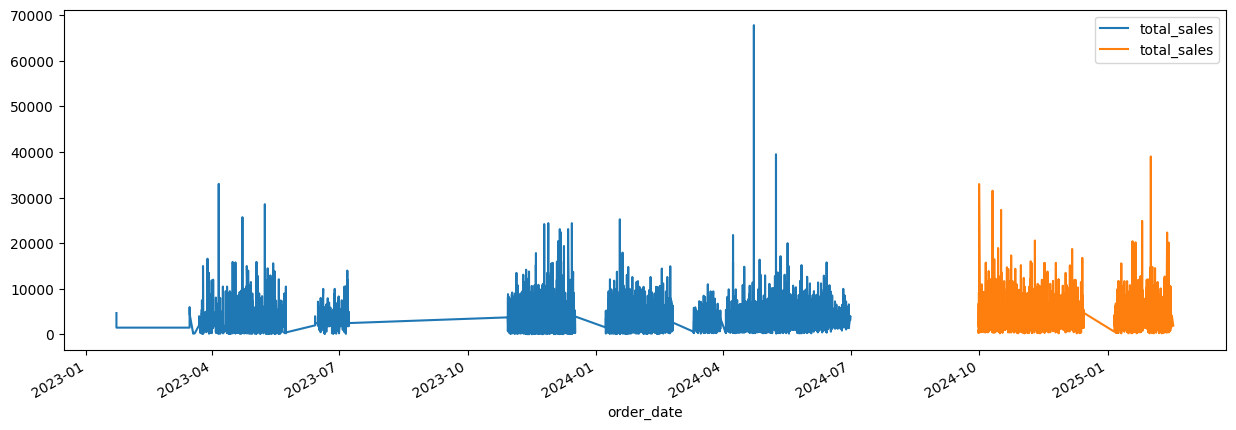

In [68]:
train_sales = train_data[['order_date','total_sales']]
test_sales = test_data[['order_date','total_sales']]


fig, ax = plt.subplots(figsize=(15,5))

train_sales.plot(x='order_date',ax=ax,kind='line')
test_sales.plot(x='order_date',ax=ax,kind='line')

plt.show()


In [69]:
train_data.columns

Index(['order_date', 'total_sales', 'average_qty', 'total_qty', 'average_freq',
       'total_freq', 'average_recency', 'total_recency', 'year', 'month',
       'weekday', 'day', 'hour'],
      dtype='object')

In [70]:
feat = ['average_qty', 'total_qty', 'average_freq',
       'total_freq', 'average_recency', 'total_recency', 'year', 'month',
       'weekday', 'day', 'hour']
target = ['total_sales']

X_train = train_data[feat]
y_train = train_data[target]

X_test = test_data[feat]
y_test = test_data[target]

In [71]:
xgb_data.sample(3)

,order_date,total_sales,average_qty,total_qty,average_freq,total_freq,average_recency,total_recency,year,month,weekday,day,hour
6275,2024-01-27 19:26:37,2150.0,1.750000,7.0,12.0,48,59.0,236,2024,1,5,27,19
8256,2024-03-24 19:38:16,5097.0,1.250000,5.0,93.0,372,285.0,1140,2024,3,6,24,19
11610,2024-05-31 16:39:28,5749.0,1.285714,9.0,8.0,56,59.0,413,2024,5,4,31,16


In [72]:
import xgboost as xgb

regressor = xgb.XGBRegressor(n_estimators=100,early_stopping_rounds=50)

regressor.fit(X_train,y_train,
              eval_set=[(X_train,y_train),(X_test,y_test)],
              verbose=True)

[0]	validation_0-rmse:2020.13802	validation_1-rmse:2193.70470
[1]	validation_0-rmse:1883.87759	validation_1-rmse:2141.16727
[2]	validation_0-rmse:1800.92747	validation_1-rmse:2103.48293
[3]	validation_0-rmse:1744.79141	validation_1-rmse:2086.73457
[4]	validation_0-rmse:1698.85621	validation_1-rmse:2084.08355
[5]	validation_0-rmse:1666.90663	validation_1-rmse:2082.53137
[6]	validation_0-rmse:1637.96804	validation_1-rmse:2087.04480
[7]	validation_0-rmse:1619.84732	validation_1-rmse:2089.73215
[8]	validation_0-rmse:1605.64192	validation_1-rmse:2084.56804
[9]	validation_0-rmse:1591.54899	validation_1-rmse:2083.21634
[10]	validation_0-rmse:1581.24285	validation_1-rmse:2081.57446
[11]	validation_0-rmse:1568.90160	validation_1-rmse:2085.15855
[12]	validation_0-rmse:1556.44276	validation_1-rmse:2088.64214
[13]	validation_0-rmse:1548.24308	validation_1-rmse:2088.65966
[14]	validation_0-rmse:1537.62543	validation_1-rmse:2096.12180
[15]	validation_0-rmse:1530.93148	validation_1-rmse:2096.17777
[1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [73]:
importance = pd.DataFrame(data=regressor.feature_importances_,index=regressor.feature_names_in_)
importance.sort_values(by=0,ascending=False,inplace=True)
importance.rename(columns={0:'importance'},inplace=True)
importance

,importance
total_qty,0.450082
year,0.085904
average_qty,0.083744
average_freq,0.061391
average_recency,0.055600
total_recency,0.054310
month,0.051583
hour,0.049326
total_freq,0.046614
day,0.033768


## Evaluation

In [74]:
test_data['prediction'] = regressor.predict(X_test)
test_data['error'] = np.absolute(test_data['total_sales'] - test_data['prediction'])

test_data.sample(6)

,order_date,total_sales,average_qty,total_qty,average_freq,total_freq,average_recency,total_recency,year,month,weekday,day,hour,prediction,error
17484,2025-01-11 20:47:00,4549.0,1.00,2.0,18.0,36,71.0,142,2025,1,5,11,20,3007.821045,1541.178955
13491,2024-10-16 18:40:32,1997.0,1.25,5.0,20.0,80,57.0,228,2024,10,2,16,18,2608.612793,611.612793
14997,2024-11-08 18:56:55,3500.0,2.00,4.0,16.0,32,54.0,108,2024,11,4,8,18,3426.564697,73.435303
16890,2024-12-06 19:29:38,9697.0,1.00,5.0,14.0,70,59.0,295,2024,12,4,6,19,3066.891846,6630.108154
17256,2025-01-06 11:32:35,3294.0,1.40,7.0,9.0,45,61.0,305,2025,1,0,6,11,2874.519043,419.480957
14356,2024-10-30 19:32:24,4045.0,1.25,5.0,46.0,184,119.0,476,2024,10,2,30,19,2718.373047,1326.626953


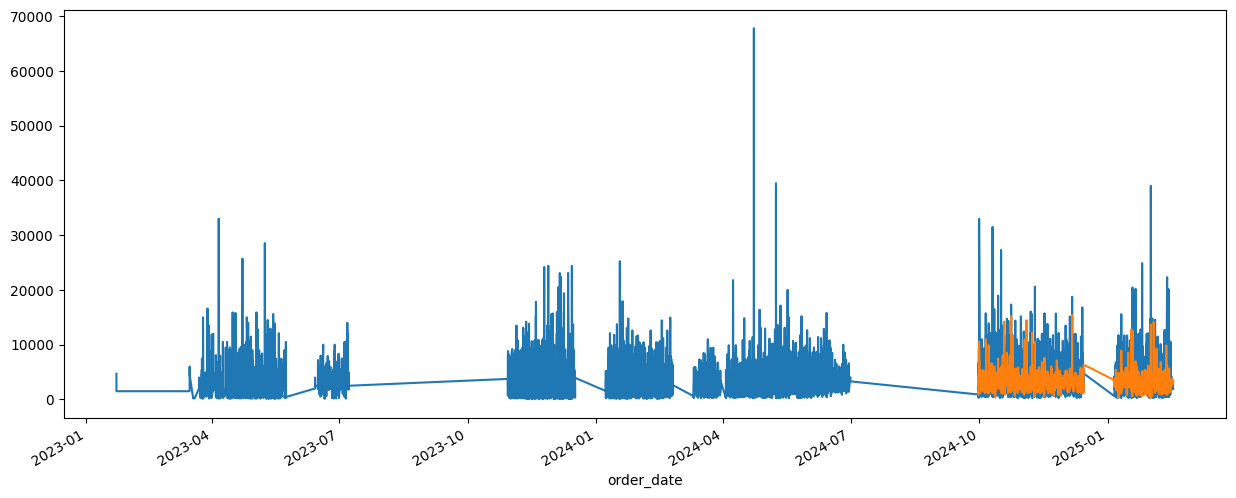

In [75]:
fig, ax = plt.subplots(figsize=(15,6))

xgb_data.groupby('order_date')['total_sales'].sum().plot(ax=ax, kind='line')
test_data.groupby('order_date')['prediction'].sum().plot(ax=ax, kind='line')

plt.show()

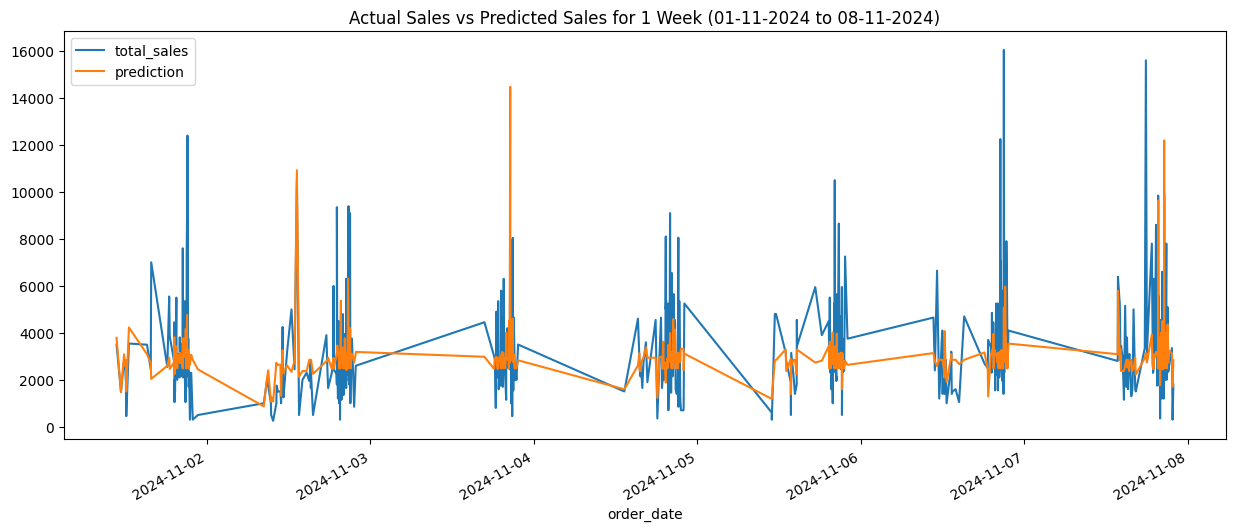

In [76]:
actual_check = test_data[(test_data['order_date']>'2024-11-01') & (test_data['order_date']<'2024-11-08')][['order_date','total_sales']]
pred_check = test_data[(test_data['order_date']>'2024-11-01') & (test_data['order_date']<'2024-11-08')][['order_date','prediction']]


fig,ax = plt.subplots(figsize=(15,6))
actual_check.plot(x='order_date', ax=ax,style='-')
pred_check.plot(x='order_date', ax=ax,style='-')

plt.title('Actual Sales vs Predicted Sales for 1 Week (01-11-2024 to 08-11-2024)')
plt.show()

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compute metrics
mae = mean_absolute_error(y_test, test_data['prediction'])
rmse = np.sqrt(mean_squared_error(y_test, test_data['prediction']))
r2 = r2_score(y_test, test_data['prediction'])

# Print results
print("\nXGBoost Accuracy Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")


XGBoost Accuracy Metrics:
Mean Absolute Error (MAE): 1313.50
Root Mean Squared Error (RMSE): 2081.57
R-squared Score (R²): 0.1292


## Time Series Models
#### ARIMA
- AR(Auto regressive): assumes that future values depend on the past values, "if sales were high yesterday, they'll be high today"
- I(Integrated): Makes data more stable by removing trends. Trends like "icecream always go up in summer"
- MA(Moving average): looks at the past prediction errors to improve future predictions. 

#### LSTM
- remembers past patterns
- forgets irrelevant information
- learns complex patterns


Let's check if our data is suitable for ARIMA

In [88]:
result.head().T

,0,1,2,3,4
id,17635318,17635318,17635318,17635318,17635318
customer_firstname,Christine,Christine,Christine,Christine,Christine
customer_lastname,Christine,Christine,Christine,Christine,Christine
customer_telephone,2347025318256.0,2347025318256.0,2347025318256.0,2347025318256.0,2347025318256.0
order_state,complete,complete,complete,complete,complete
increment_id,R27635318,R27635318,R27635318,R27635318,R27635318
order_date,2025-02-16 20:46:12,2025-02-16 20:46:12,2025-02-16 20:46:12,2025-02-16 20:46:12,2025-02-16 20:46:12
clerk_id,267702.0,267702.0,267702.0,267702.0,267702.0
clerk_name,Amiegbereta Marvellous,Amiegbereta Marvellous,Amiegbereta Marvellous,Amiegbereta Marvellous,Amiegbereta Marvellous
delivery_address,"Benson Idahosa University Legacy Campus,,NG","Benson Idahosa University Legacy Campus,,NG","Benson Idahosa University Legacy Campus,,NG","Benson Idahosa University Legacy Campus,,NG","Benson Idahosa University Legacy Campus,,NG"


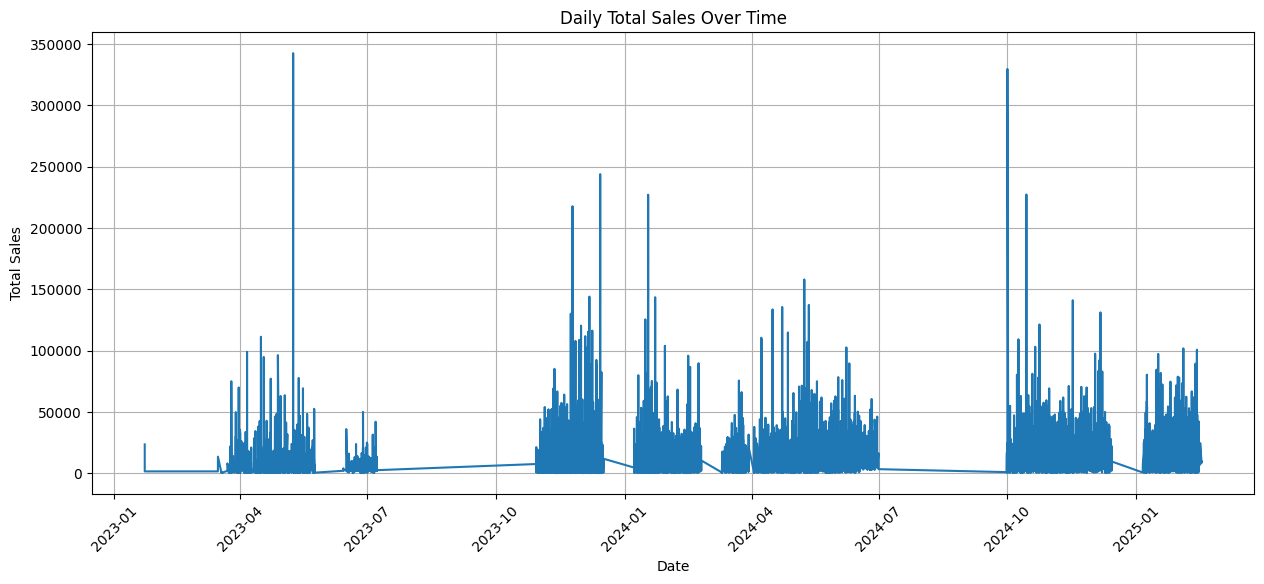


Basic Statistics:
count     19956.000000
mean      10901.815745
std       11836.641617
min          50.000000
25%        3900.000000
50%        7939.500000
75%       14008.500000
max      342516.000000
Name: total_amount_paid_for_order, dtype: float64

Missing Values: 0

Time Series Characteristics:
Start Date: 2023-01-22 16:19:31
End Date: 2025-02-16 20:46:12
Number of Days: 19956


In [89]:
# 1. First, let's prepare our time series data
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by order_date and sum the total_amount_paid_for_order
ts_data = result.groupby('order_date')['total_amount_paid_for_order'].sum()

# Sort by date
ts_data = ts_data.sort_index()

# Basic visualization
plt.figure(figsize=(15, 6))
plt.plot(ts_data)
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Check basic statistics
print("\nBasic Statistics:")
print(ts_data.describe())

# Check for missing values
print("\nMissing Values:", ts_data.isnull().sum())

# Check time series characteristics
print("\nTime Series Characteristics:")
print("Start Date:", ts_data.index.min())
print("End Date:", ts_data.index.max())
print("Number of Days:", len(ts_data))

- High volatility in sales
- Possible seasonal patterns with regular peaks
- High standard deviation (11,836) relative to mean (10,901) indicates high variability

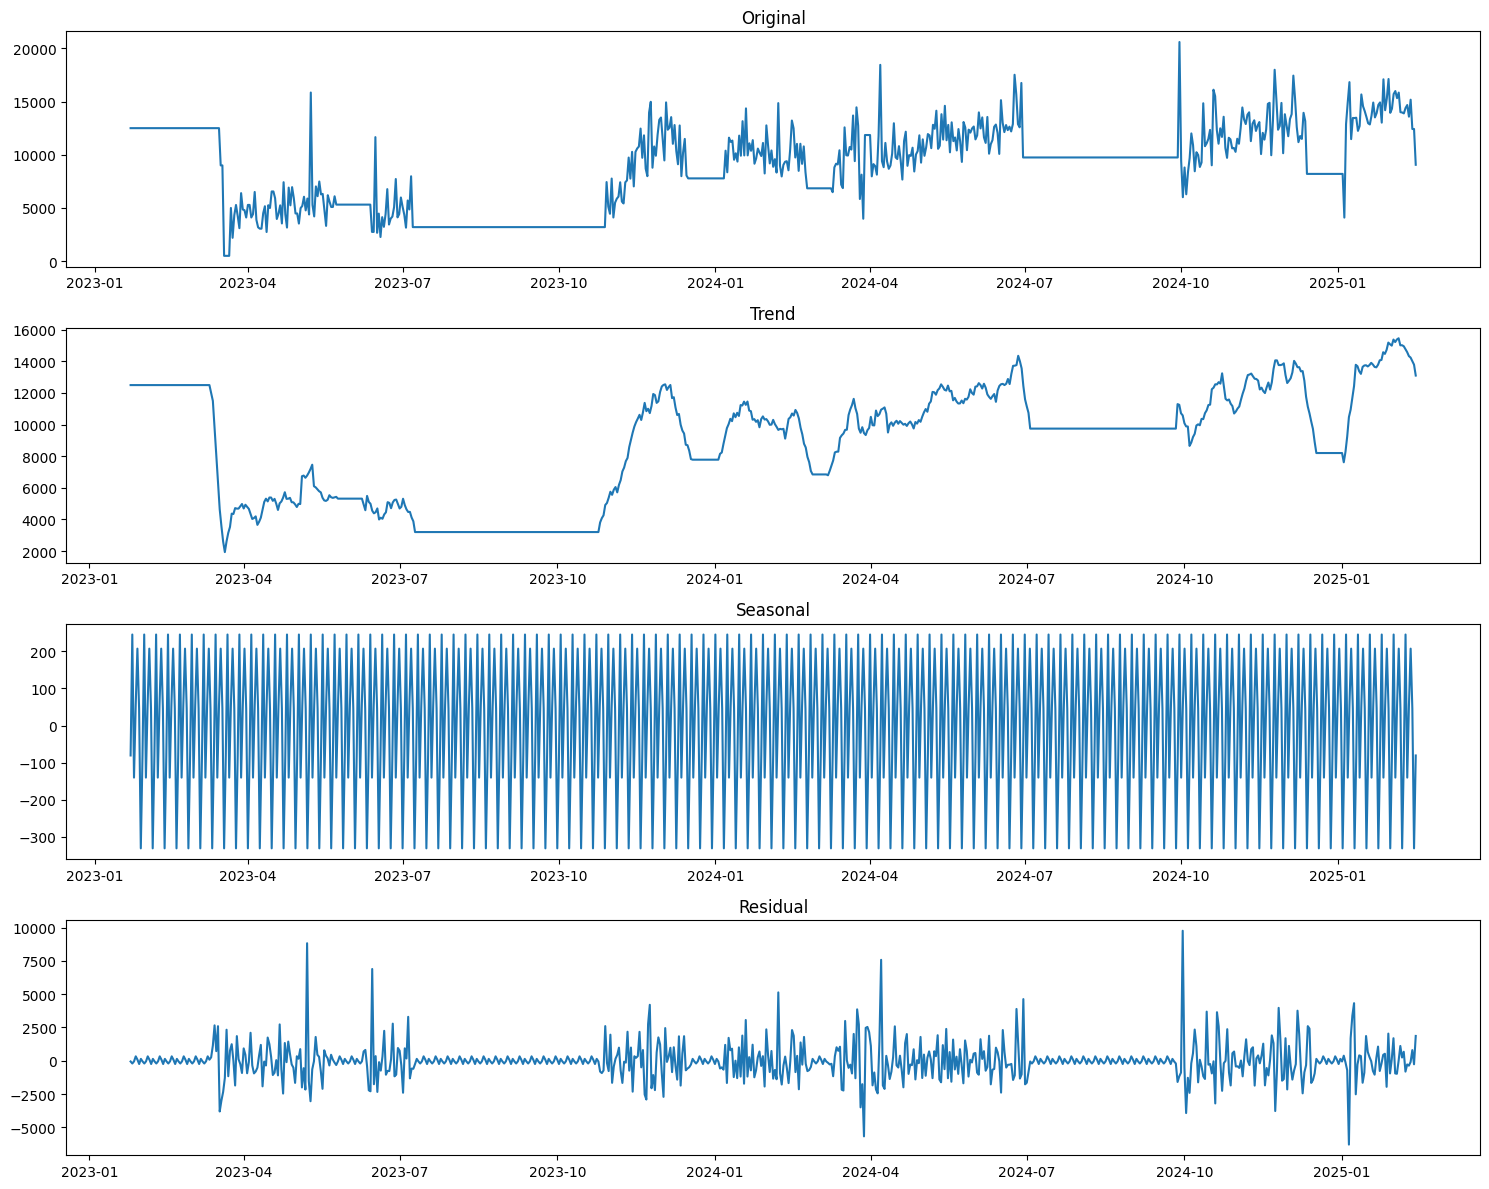


Stationarity Test Results:
ADF Statistic: -2.4891305801613837
p-value: 0.11814142079279633
Critical values:
	1%: -3.439
	5%: -2.865
	10%: -2.569


In [90]:
# 1. Test for stationarity using Augmented Dickey-Fuller test
def check_stationarity(data):
    result = adfuller(data)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

# 2. Decompose the series to see trends and seasonality
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to daily data for clearer patterns
daily_data = ts_data.resample('D').mean().fillna(method='ffill')

# Perform decomposition
decomposition = seasonal_decompose(daily_data, period=7)  # assuming weekly seasonality

# Plot decomposition
plt.figure(figsize=(15, 12))
plt.subplot(411)
plt.plot(daily_data)
plt.title('Original')
plt.subplot(412)
plt.plot(decomposition.trend)
plt.title('Trend')
plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.title('Seasonal')
plt.subplot(414)
plt.plot(decomposition.resid)
plt.title('Residual')
plt.tight_layout()
plt.show()

# Check stationarity
print("\nStationarity Test Results:")
check_stationarity(daily_data)

- p-value = 0.118 > 0.05: Data is non-stationary
- ADF Statistic (-2.489) > Critical values: Confirms non-stationarity
- This means we need to transform our data before applying ARIMA

### Making data stationary
* differenced data is more likely to be stationary because we've removed the upward trend, focusing instead on the changes between observations.

In [91]:
daily_data

order_date
2023-01-22    12500.000000
2023-01-23    12500.000000
2023-01-24    12500.000000
2023-01-25    12500.000000
2023-01-26    12500.000000
                  ...     
2025-02-12    13582.000000
2025-02-13    15174.459016
2025-02-14    12420.279070
2025-02-15    12422.181818
2025-02-16     9057.000000
Freq: D, Name: total_amount_paid_for_order, Length: 757, dtype: float64

Stationarity Test After First Differencing:
ADF Statistic: -16.477517417616344
p-value: 2.253108343181136e-29
Critical values:
	1%: -3.439
	5%: -2.865
	10%: -2.569


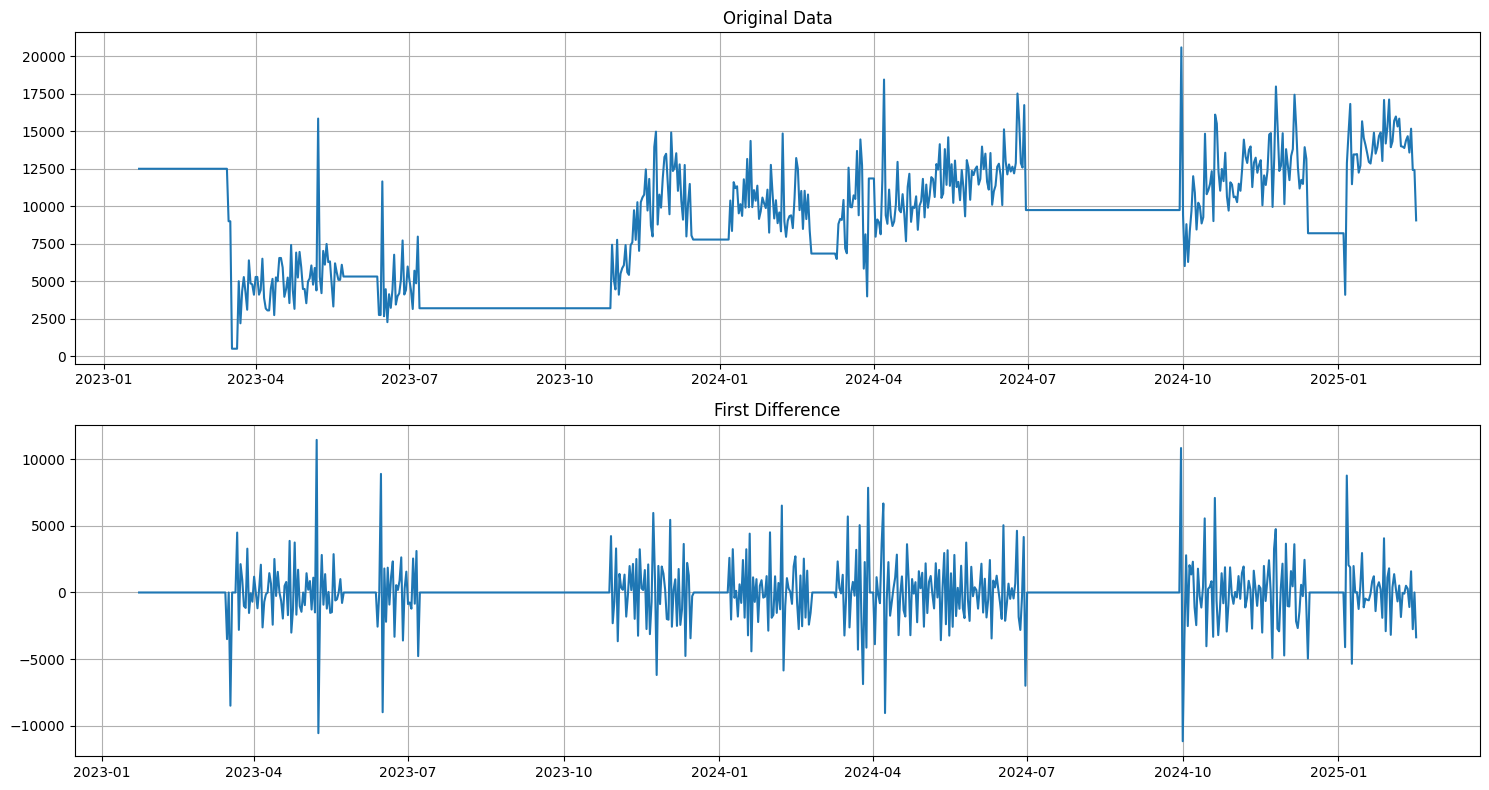

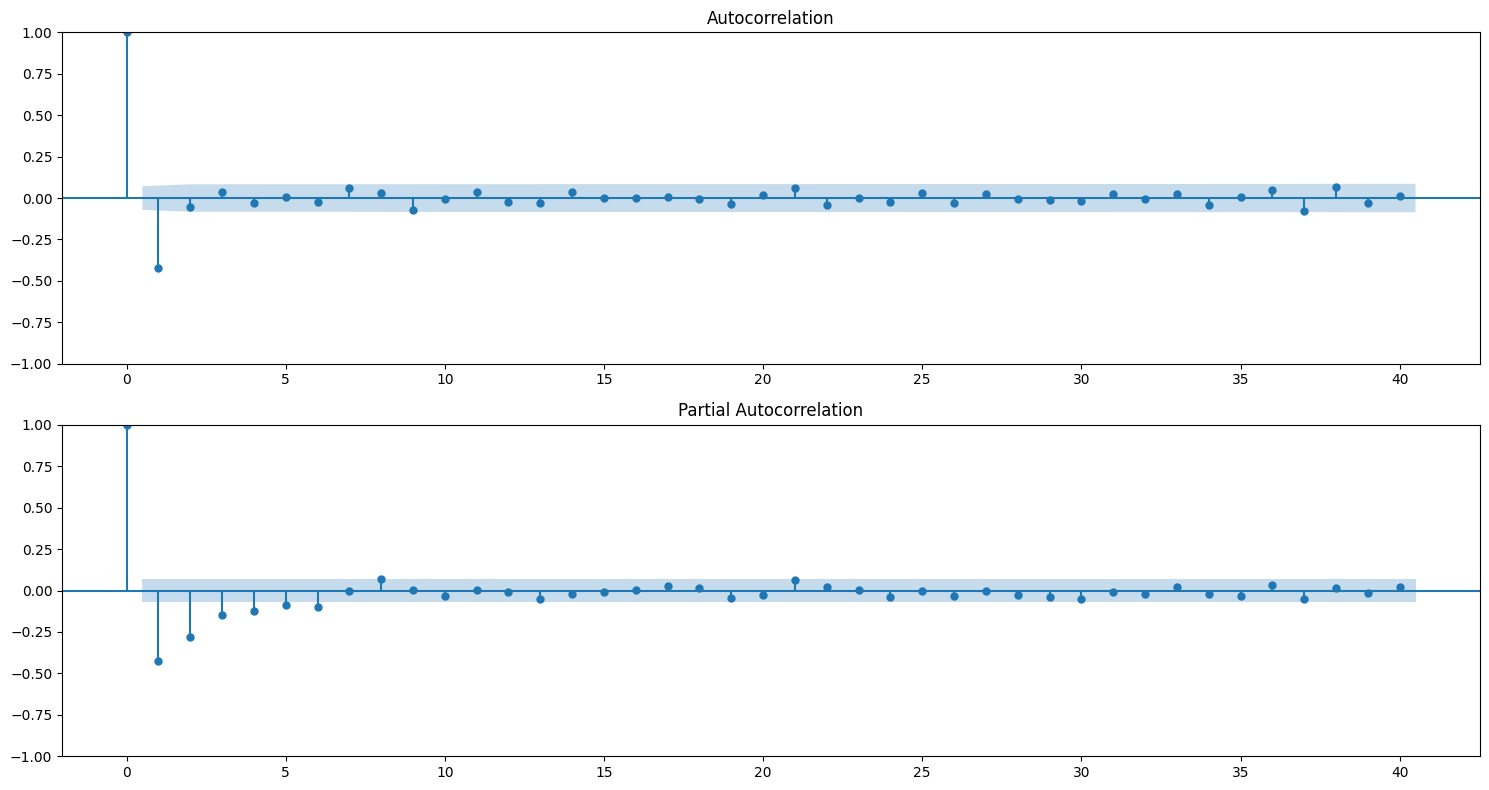

In [92]:
# 1. First difference to remove trend
diff_1 = daily_data.diff().dropna()

# 2. Check stationarity of differenced data
print("Stationarity Test After First Differencing:")
check_stationarity(diff_1)

# Plot original vs differenced data
fig, ax = plt.subplots(2, 1, figsize=(15, 8))
ax[0].plot(daily_data)
ax[0].set_title('Original Data')
ax[0].grid(True)

ax[1].plot(diff_1)
ax[1].set_title('First Difference')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# 3. Plot ACF and PACF to determine p,q values
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
plot_acf(diff_1, ax=ax1, lags=40)
plot_pacf(diff_1, ax=ax2, lags=40)
plt.tight_layout()
plt.show()

1. Stationarity Test After Differencing:
    - p-value is extremely small (2.25e-29 << 0.05): Data is now stationary
    - ADF Statistic (-16.48) is much lower than all critical values: Strongly confirms stationarity
    - This means our differencing worked well!
2. ACF/PACF Plot Analysis:
    - ACF (Autocorrelation Function):
      - Strong negative spike at lag 1
      - Most values within significance bounds after that
      - Suggests MA(1) component
    - PACF (Partial Autocorrelation Function):
      - Similar pattern with strong negative spike at lag 1
      - Suggests AR(1) componen

In [95]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA parameters:
# (p,d,q) = (1,1,1) for non-seasonal part
# (P,D,Q,s) = (1,1,1,7) for seasonal part (weekly seasonality)

                                     SARIMAX Results                                     
Dep. Variable:       total_amount_paid_for_order   No. Observations:                  697
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -6033.115
Date:                           Mon, 17 Mar 2025   AIC                          12076.230
Time:                                   23:25:05   BIC                          12098.841
Sample:                               01-22-2023   HQIC                         12084.982
                                    - 12-18-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0462      0.038      1.222      0.222      -0.028       0.120
ma.L1         -0.6958      0.029    -24.241

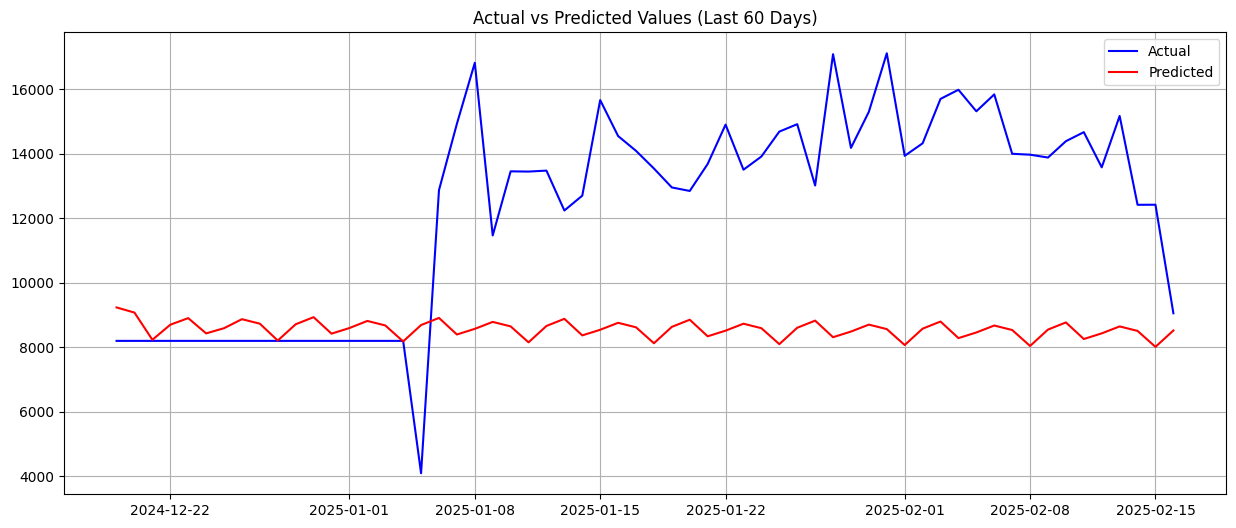

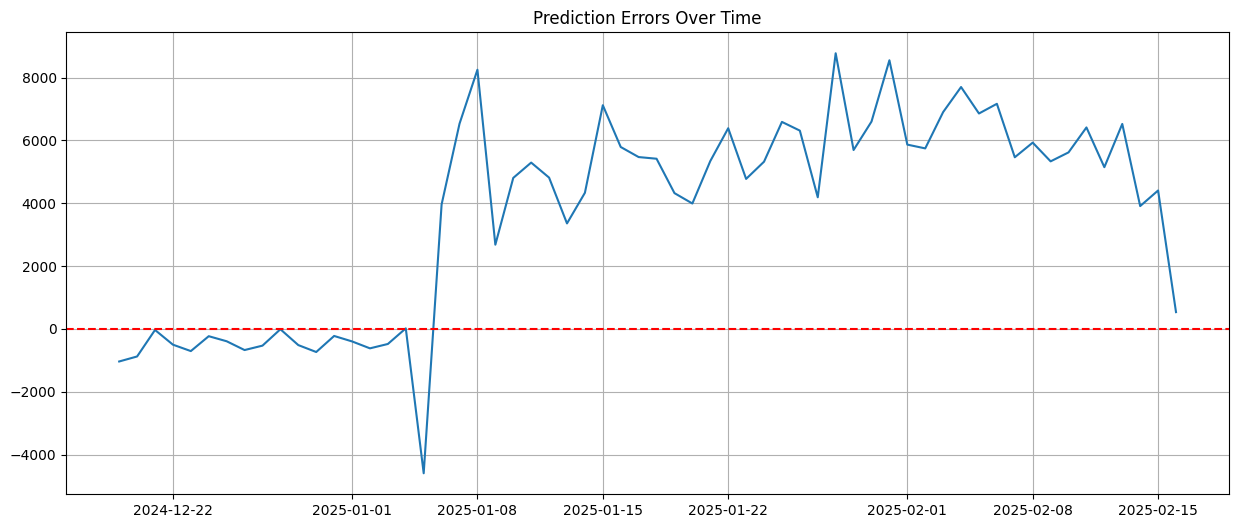

In [96]:
# 1. Split data into train and test sets (using last 60 days as test)
train_data = daily_data[:-60]
test_data = daily_data[-60:]

# 2. Fit model on training data
model = SARIMAX(train_data,
                order=(1,1,1),
                seasonal_order=(1,1,1,7),
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit()
print(model_fit.summary())

# 3. Make predictions for test period
forecast = model_fit.forecast(steps=len(test_data))

# 4. Calculate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test_data, forecast)
rmse = np.sqrt(mean_squared_error(test_data, forecast))
mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
r2 = r2_score(test_data, forecast)

print('\nAccuracy Metrics:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'R-squared Score: {r2:.4f}')

# 5. Plot actual vs predicted
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data, label='Actual', color='blue')
plt.plot(test_data.index, forecast, label='Predicted', color='red')
plt.title('Actual vs Predicted Values (Last 60 Days)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Plot prediction errors
errors = test_data - forecast
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, errors)
plt.title('Prediction Errors Over Time')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.show()

In [99]:
# Create a properly aligned forecast Series
forecast_series = pd.Series(data=forecast.values, index=test_data.index)

comparison_df = pd.DataFrame({
    'Actual': test_data,
    'Predicted': forecast_series
})

comparison_df.tail()

,Actual,Predicted
order_date,,
2025-02-12,13582.000000,8432.864833
2025-02-13,15174.459016,8648.267778
2025-02-14,12420.279070,8509.239000
2025-02-15,12422.181818,8014.695992
2025-02-16,9057.000000,8522.525137


#### LSTM

In [110]:
ts_data.index = pd.to_datetime(ts_data.index)  # Convert index to datetime

def create_features(data):
    df = pd.DataFrame(data)  
    df['sales'] = df['total_amount_paid_for_order']  
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day'] = df.index.day
    return df

data_with_features = create_features(daily_data)

print("Data shape:", data_with_features.shape)
print("\nFirst few rows:")
print(data_with_features.head())


Data shape: (757, 5)

First few rows:
            total_amount_paid_for_order    sales  dayofweek  month  day
order_date                                                             
2023-01-22                      12500.0  12500.0          6      1   22
2023-01-23                      12500.0  12500.0          0      1   23
2023-01-24                      12500.0  12500.0          1      1   24
2023-01-25                      12500.0  12500.0          2      1   25
2023-01-26                      12500.0  12500.0          3      1   26


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.1139 - val_loss: 0.0190
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0211 - val_loss: 0.0104
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0143 - val_loss: 0.0115
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0121 - val_loss: 0.0149
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0109 - val_loss: 0.0098
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0093 - val_loss: 0.0099
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0095 - val_loss: 0.0110
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0112 - val_loss: 0.0120
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0108 - val_loss: 0.0096
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0101 - val_loss: 0.0093
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0085 - val_loss: 0.0112
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

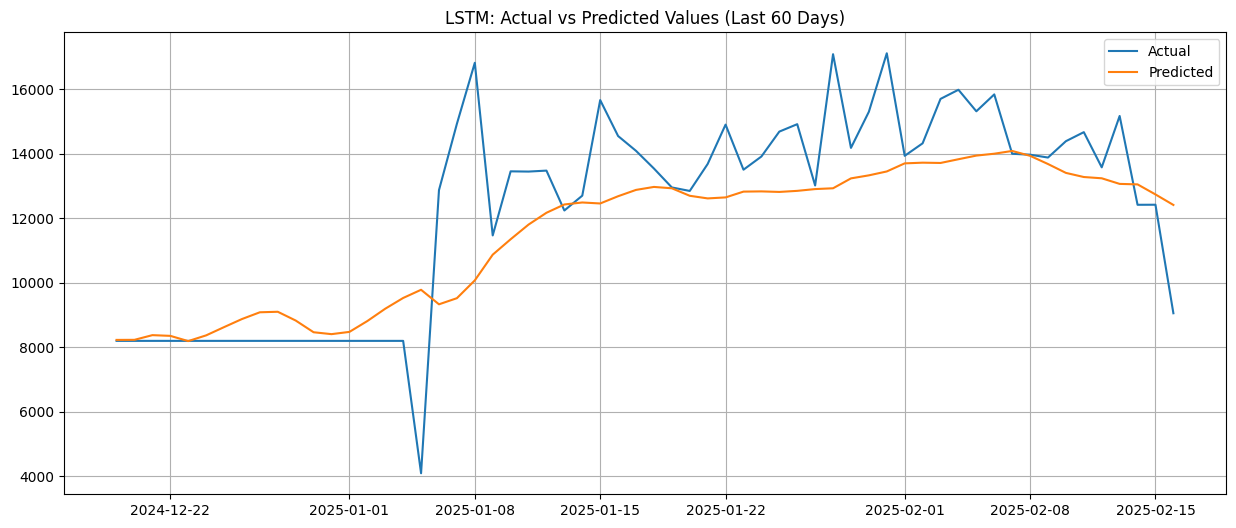

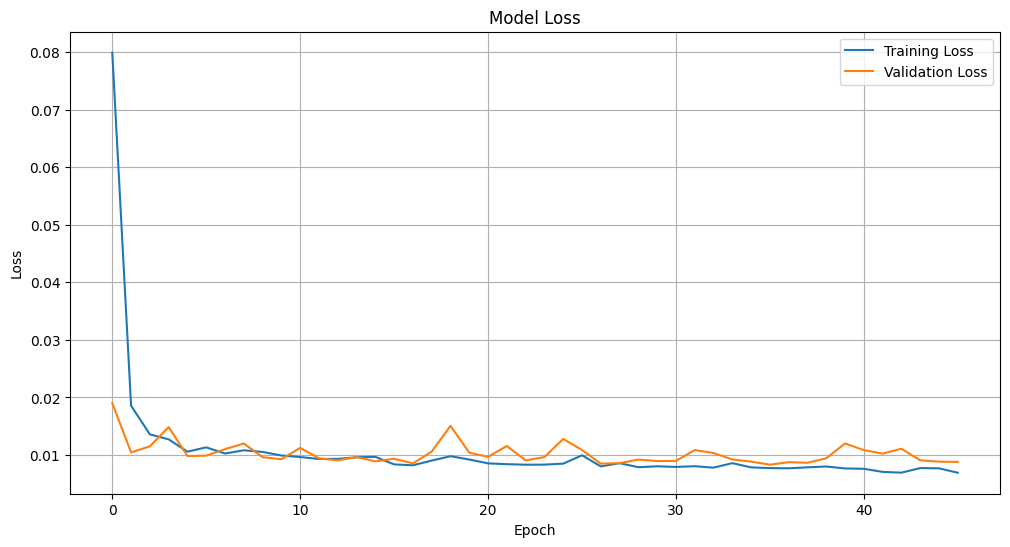

In [111]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_with_features)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, 0])  # First column is the target (sales)
    return np.array(X), np.array(y)

# Use 14 days to predict next day
sequence_length = 14
X, y = create_sequences(scaled_data, sequence_length)

# Split into train and test (last 60 days for testing)
train_size = len(X) - 60
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. Build LSTM model
model = Sequential([
    LSTM(100, activation='relu', input_shape=(sequence_length, scaled_data.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile model with learning rate scheduling
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# 6. Train the model with early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
# Create dummy arrays with same shape as original data
train_predict_reshaped = np.zeros((len(train_predict), scaled_data.shape[1]))
train_predict_reshaped[:, 0] = train_predict.flatten()
test_predict_reshaped = np.zeros((len(test_predict), scaled_data.shape[1]))
test_predict_reshaped[:, 0] = test_predict.flatten()

# Inverse transform
train_predict = scaler.inverse_transform(train_predict_reshaped)[:, 0]
test_predict = scaler.inverse_transform(test_predict_reshaped)[:, 0]

# Calculate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get actual values
y_test_actual = scaler.inverse_transform(np.zeros((len(y_test), scaled_data.shape[1])))[:, 0]
y_test_actual[:] = daily_data.values[train_size+sequence_length:]

print('\nAccuracy Metrics:')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y_test_actual, test_predict):.2f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_actual, test_predict)):.2f}')
print(f'R-squared Score: {r2_score(y_test_actual, test_predict):.4f}')

# Plot results
plt.figure(figsize=(15, 6))
plt.plot(daily_data.index[-60:], y_test_actual, label='Actual')
plt.plot(daily_data.index[-60:], test_predict, label='Predicted')
plt.title('LSTM: Actual vs Predicted Values (Last 60 Days)')
plt.legend()
plt.grid(True)
plt.show()

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

##### Comparison with SARIMA
LSTM performs better at:
- Capturing trends
- Following the general pattern
- Adapting to level changes
- More realistic predictions compared to SARIMA's flat predictions

#### Prophet

00:02:40 - cmdstanpy - INFO - Chain [1] start processing
00:02:50 - cmdstanpy - INFO - Chain [1] done processing



Accuracy Metrics:
Mean Absolute Error (MAE): 8307.65
Root Mean Squared Error (RMSE): 9537.24
R-squared Score: -0.1618


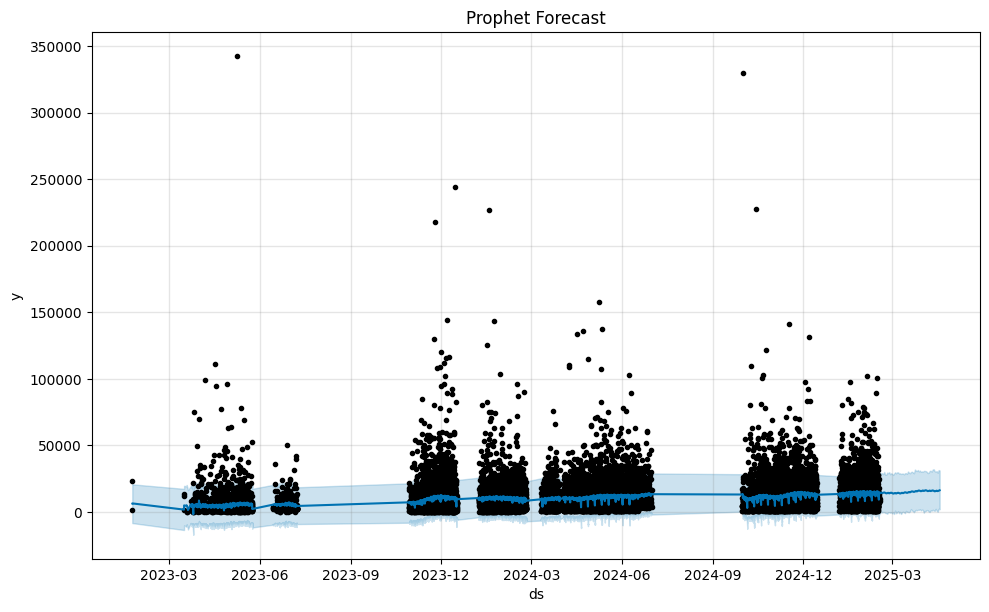

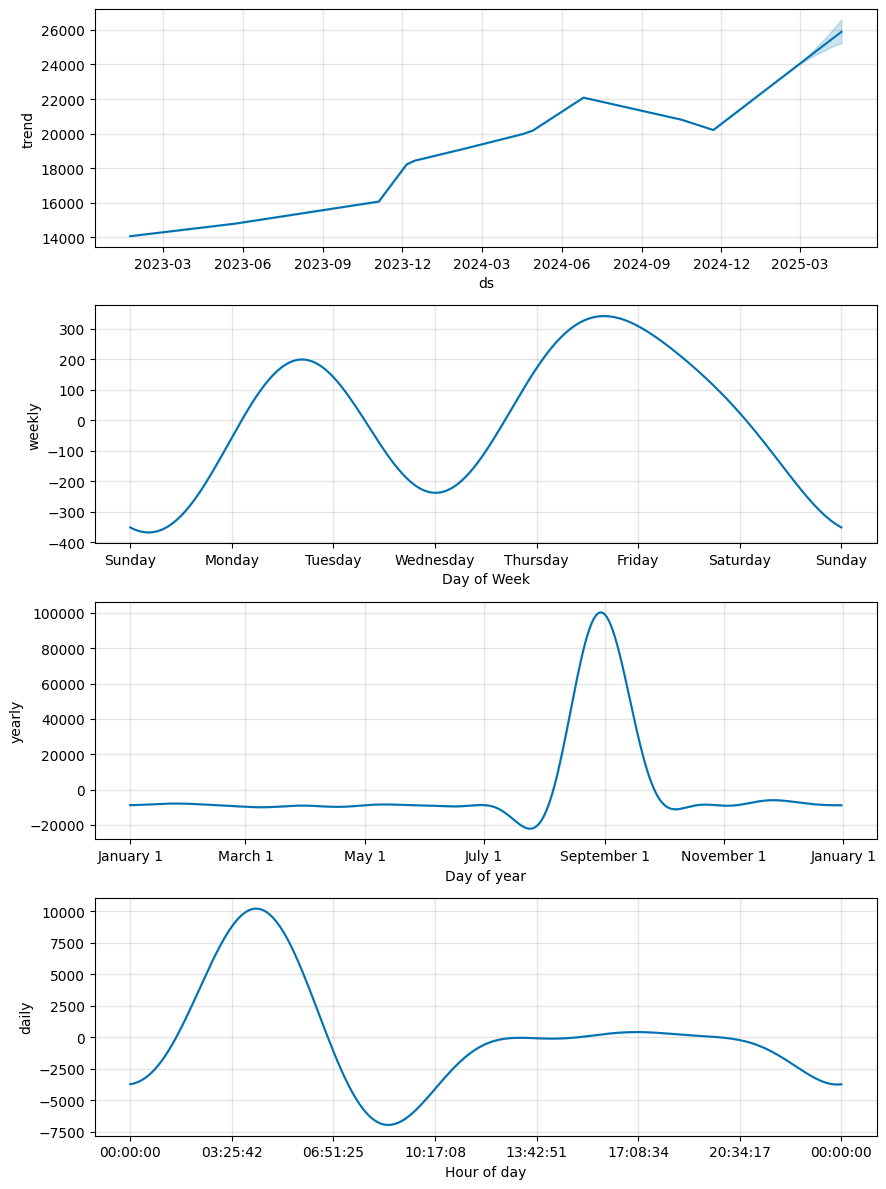

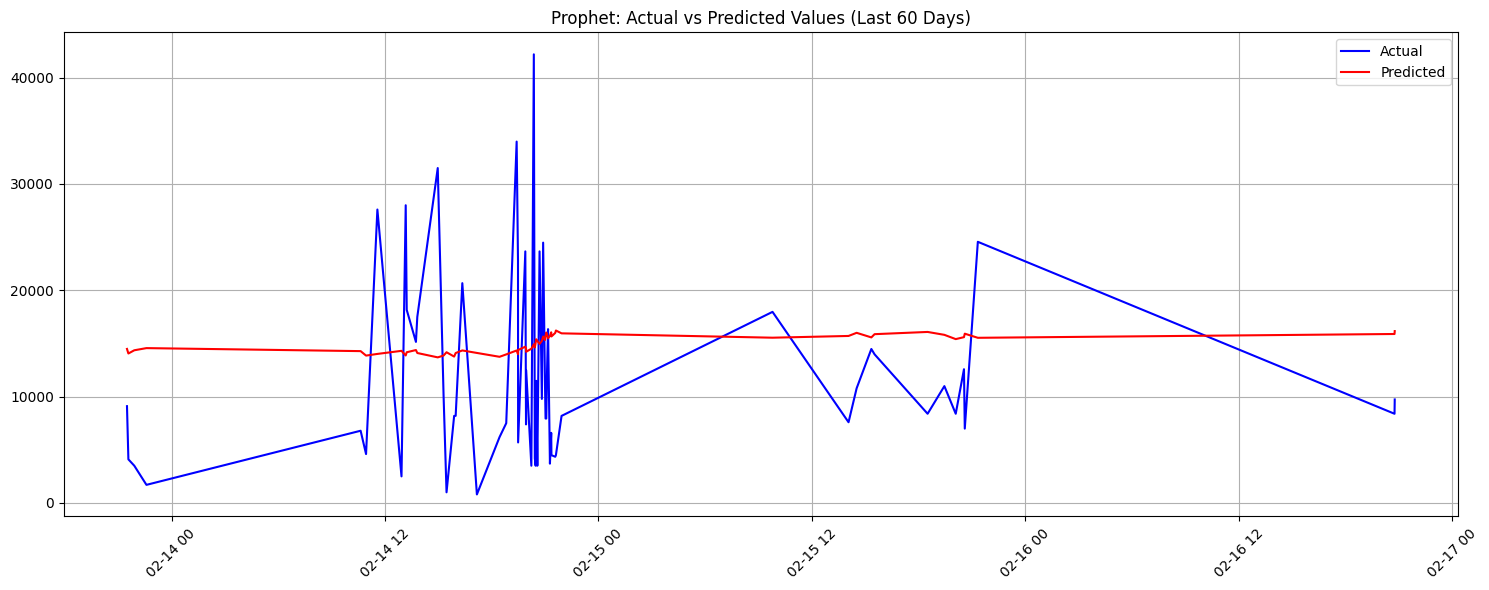

In [114]:
# Import Prophet and other required libraries
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Prepare data for Prophet (requires 'ds' for dates and 'y' for values)
prophet_data = pd.DataFrame({
    'ds': ts_data.index,
    'y': ts_data.values
})

# 2. Create and fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    changepoint_prior_scale=0.05,  # Flexibility of trend changes
    seasonality_prior_scale=10     # Flexibility of seasonality
)

# Fit the model
model.fit(prophet_data)

# 3. Create future dates for prediction (including our test period)
future_dates = model.make_future_dataframe(periods=60, freq='D')

# 4. Make predictions
forecast = model.predict(future_dates)

# 5. Calculate accuracy metrics for the last 60 days
actual_values = prophet_data['y'].iloc[-60:].values
predicted_values = forecast['yhat'].iloc[-60:].values

mae = mean_absolute_error(actual_values, predicted_values)
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
r2 = r2_score(actual_values, predicted_values)

print('\nAccuracy Metrics:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared Score: {r2:.4f}')

# 6. Plotting
# Plot the entire forecast
fig1 = model.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

# Plot components (trend, weekly seasonality, yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()

# Plot actual vs predicted for last 60 days
plt.figure(figsize=(15, 6))
plt.plot(prophet_data['ds'].iloc[-60:], actual_values, label='Actual', color='blue')
plt.plot(prophet_data['ds'].iloc[-60:], predicted_values, label='Predicted', color='red')
plt.title('Prophet: Actual vs Predicted Values (Last 60 Days)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Overall Performance (worse than LSTM):
- High MAE (8,307.65) and RMSE (9,537.24)
- Negative R² (-0.1618) indicates the model performs worse than a horizontal line
- Much poorer performance compared to LSTM (which had R² = 0.5974)

Importing plotly failed. Interactive plots will not work.
11:14:43 - cmdstanpy - INFO - Chain [1] start processing
11:14:43 - cmdstanpy - INFO - Chain [1] done processing


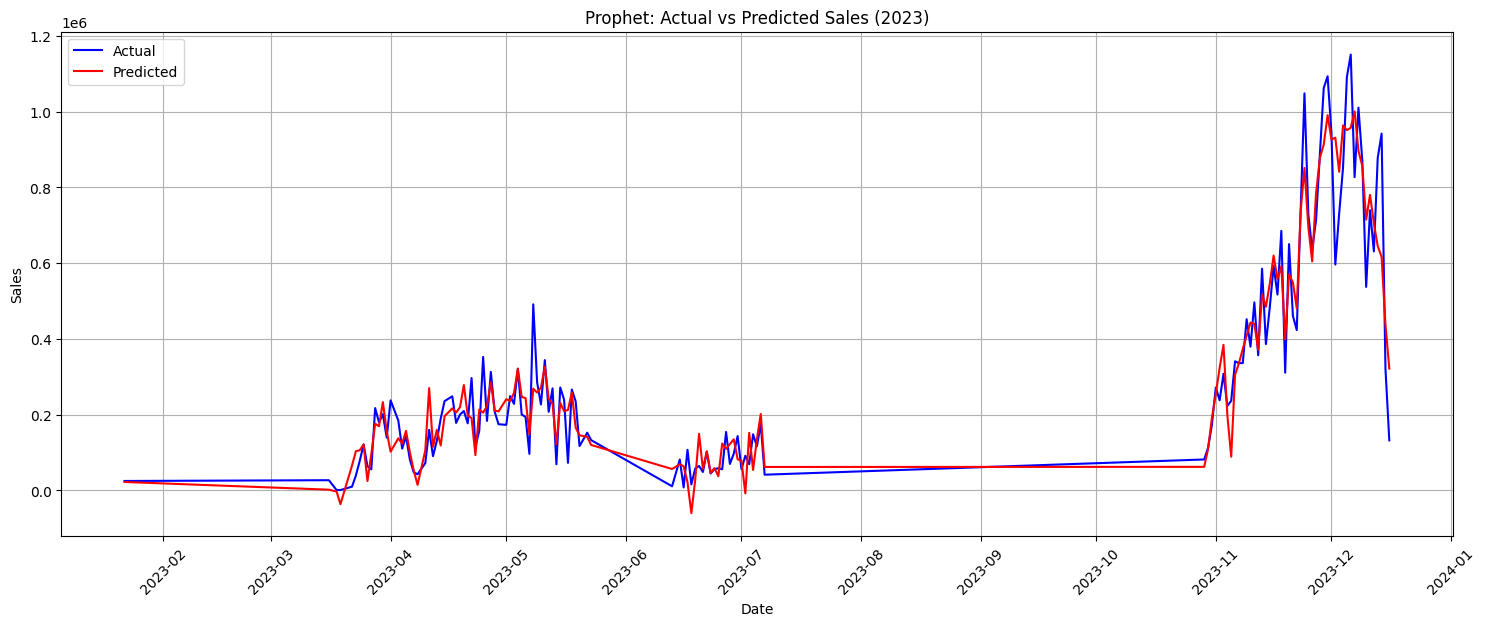

In [78]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
df_2023_filled = pd.read_csv("daily_sales_2023.csv", parse_dates=["Date"])
df_2023_filled = df_2023_filled.rename(columns={"Date": "ds", "Total Sales": "y"})

# Define school break dates as holidays
holidays = pd.DataFrame({
    'holiday': 'school_closure',
    'ds': pd.to_datetime([
        '2023-01-23', '2023-03-15',  # Jan to mid-March
        '2023-05-24', '2023-06-12',  # May to June
        '2023-07-08', '2023-10-28'   # July to October
    ]),
    'lower_window': 0,
    'upper_window': 30
})

# Create and configure Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.5,     # increase trend flexibility
    seasonality_prior_scale=20,      # stronger seasonality influence
    holidays=holidays
)

# Fit model
model.fit(df_2023_filled)

# Forecast
future = model.make_future_dataframe(periods=0, freq='D')
forecast = model.predict(future)

# Merge actual and predicted for plotting
merged = df_2023_filled.merge(forecast[['ds', 'yhat']], on='ds')

# Plot actual vs predicted
plt.figure(figsize=(15, 6))
plt.plot(merged['ds'], merged['y'], label='Actual', color='blue')
plt.plot(merged['ds'], merged['yhat'], label='Predicted', color='red')
plt.title('Prophet: Actual vs Predicted Sales (2023)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [79]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
mae = mean_absolute_error(merged['y'], merged['yhat'])
r2 = r2_score(merged['y'], merged['yhat'])

# Print results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")

Mean Absolute Error (MAE): 59055.30
Root Mean Squared Error (RMSE): 83574.30
R-squared Score (R²): 0.9141


Focusing on LSTM Model
- Enhanced Feature Engineering
    - Adding lag features
    - Adding rolling stone statistices
    - Using RobustScaler to handle outlier better
    - longer sequence length of 21 days
    - using Bidirectional LSTM layers

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1083

17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 413ms/step - loss: 0.1069 - val_loss: 0.0422
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0520 - val_loss: 0.0477
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0428 - val_loss: 0.0478
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0428 - val_loss: 0.0504
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0369

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0369 - val_loss: 0.0407
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0343 - val_loss: 0.0499
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0362 - val_loss: 0.0410
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0359 - val_loss: 0.0413
Epoch 9/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0329 - val_loss: 0.0443
Epoch 10/150
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0343

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0341 - val_loss: 0.0403
Epoch 11/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0254 - val_loss: 0.0521
Epoch 12/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0354

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0352 - val_loss: 0.0382
Epoch 13/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0327 - val_loss: 0.0384
Epoch 14/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0280 - val_loss: 0.0434
Epoch 15/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0313 - val_loss: 0.0418
Epoch 16/150
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0287

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0286 - val_loss: 0.0379
Epoch 17/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0309 - val_loss: 0.0424
Epoch 18/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0277 - val_loss: 0.0429
Epoch 19/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0267

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0268 - val_loss: 0.0368
Epoch 20/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0291 - val_loss: 0.0404
Epoch 21/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0280 - val_loss: 0.0414
Epoch 22/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0289 - val_loss: 0.0382
Epoch 23/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0287 - val_loss: 0.0375
Epoch 24/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0297 - val_loss: 0.0529
Epoch 25/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0259 - val_loss: 0.0401
Epoch 26/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0248 - val_loss: 0.0413
Epoch 27/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0312 - val_loss: 0.0402
Epoch 28/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0249 - val_loss: 0.0427
Epoch 29/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0246 - val_loss: 0.0445
Epoch 30/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - l

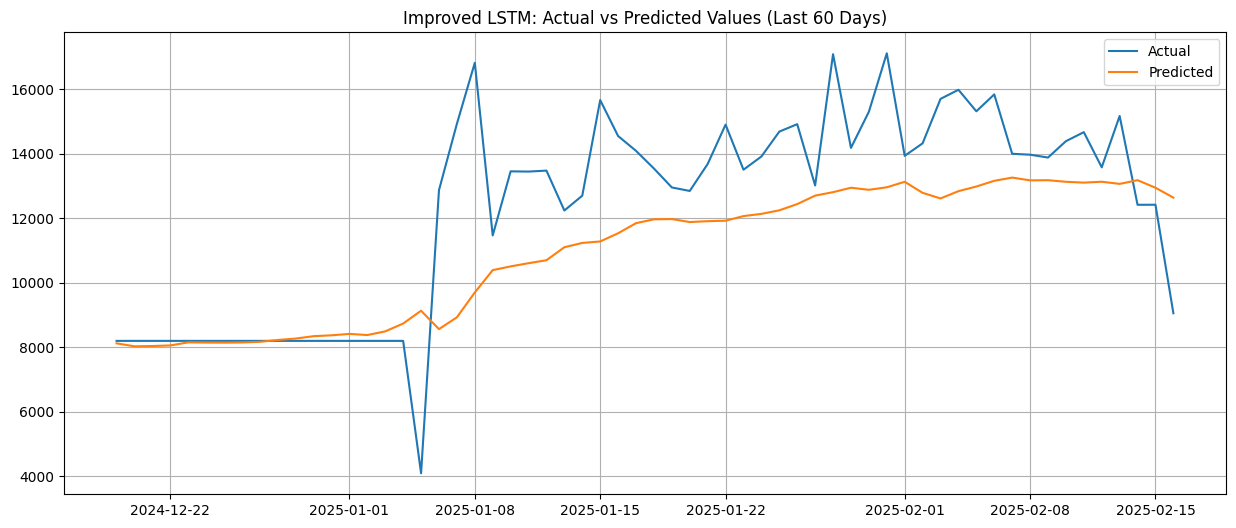

In [115]:
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint


# 1. Enhanced feature engineering
def create_features(data):
    df = pd.DataFrame(data)
    
    # Time-based features
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day'] = df.index.day
    
    # Add lag features
    df['sales_lag1'] = df['total_amount_paid_for_order'].shift(1)
    df['sales_lag7'] = df['total_amount_paid_for_order'].shift(7)  # Weekly lag
    
    # Add rolling means
    df['rolling_mean_7'] = df['total_amount_paid_for_order'].rolling(window=7).mean()
    df['rolling_std_7'] = df['total_amount_paid_for_order'].rolling(window=7).std()
    
    # Fill NaN values
    df = df.fillna(method='bfill')
    return df

# 2. Prepare data
daily_data = ts_data.resample('D').mean().fillna(method='ffill')
data_with_features = create_features(daily_data)

# 3. Scale the data using RobustScaler (handles outliers better)
scaler = RobustScaler()
scaled_data = scaler.fit_transform(data_with_features)

# 4. Enhanced sequence creation
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, 0])  # First column is the target
    return np.array(X), np.array(y)

sequence_length = 21  # Increased to capture 3 weeks of patterns
X, y = create_sequences(scaled_data, sequence_length)

# 5. Train-test split
train_size = len(X) - 60
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 6. Enhanced LSTM model
model = Sequential([
    Bidirectional(LSTM(128, activation='relu', return_sequences=True), 
                 input_shape=(sequence_length, scaled_data.shape[1])),
    Dropout(0.3),
    Bidirectional(LSTM(64, activation='relu')),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

# 7. Compile with learning rate scheduling
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='huber')  # Huber loss handles outliers better

# 8. Enhanced callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# 9. Train the model
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# 10. Make predictions and evaluate
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Prepare for inverse transform
train_predict_full = np.zeros((len(train_predict), scaled_data.shape[1]))
train_predict_full[:, 0] = train_predict.flatten()
test_predict_full = np.zeros((len(test_predict), scaled_data.shape[1]))
test_predict_full[:, 0] = test_predict.flatten()

# Inverse transform
train_predict = scaler.inverse_transform(train_predict_full)[:, 0]
test_predict = scaler.inverse_transform(test_predict_full)[:, 0]

# Get actual values
y_test_actual = scaler.inverse_transform(np.zeros((len(y_test), scaled_data.shape[1])))[:, 0]
y_test_actual[:] = daily_data.values[train_size+sequence_length:]

# Calculate metrics
mae = mean_absolute_error(y_test_actual, test_predict)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
r2 = r2_score(y_test_actual, test_predict)

print('\nImproved Model Accuracy Metrics:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared Score: {r2:.4f}')

# Plot results
plt.figure(figsize=(15, 6))
plt.plot(daily_data.index[-60:], y_test_actual, label='Actual')
plt.plot(daily_data.index[-60:], test_predict, label='Predicted')
plt.title('Improved LSTM: Actual vs Predicted Values (Last 60 Days)')
plt.legend()
plt.grid(True)
plt.show()

Further Optimization next
- Reducing feature set to most important ones
- Using Shorter sequence length (10 days)
- Simpler but deeper architecture
- Back to MinMaxScaler
- Removed Bidirectional layers

Epoch 1/150
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0531

18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 318ms/step - loss: 0.0508 - val_loss: 0.0138
Epoch 2/150
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0098

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0097 - val_loss: 0.0056
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0066 - val_loss: 0.0057
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0057

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0057 - val_loss: 0.0047
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0060 - val_loss: 0.0049
Epoch 6/150
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0059

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0059 - val_loss: 0.0046
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0050 - val_loss: 0.0066
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0052 - val_loss: 0.0072
Epoch 9/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0055 - val_loss: 0.0046
Epoch 10/150
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0058

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0058 - val_loss: 0.0045
Epoch 11/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0053 - val_loss: 0.0047
Epoch 12/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0043 - val_loss: 0.0050
Epoch 13/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0055 - val_loss: 0.0057
Epoch 14/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0043

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 15/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 16/150
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0048

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0048 - val_loss: 0.0044
Epoch 17/150
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0042

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 18/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 19/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 20/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0043 - val_loss: 0.0049
Epoch 21/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 22/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 23/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 24/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0036 - val_loss: 0.0045
Epoch 25/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0047 - val_loss: 0.0054
Epoch 26/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0037 - val_loss: 0.0052
Epoch 27/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0036 - val_loss: 0.0044
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step
2/2 ━━━━━━━━━━━

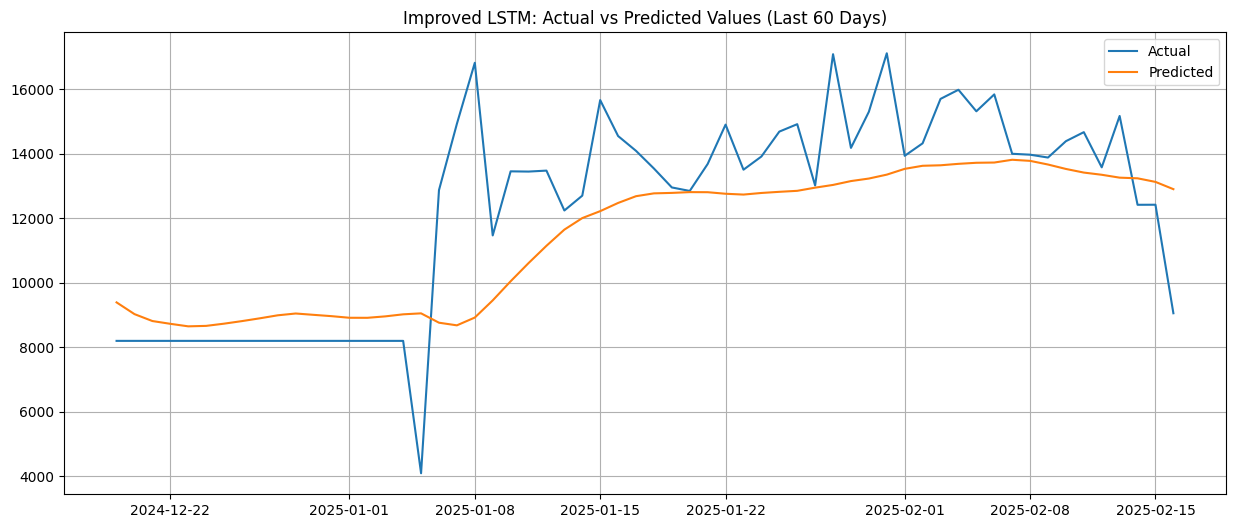

In [118]:
# 1. Enhanced feature engineering
def create_features(data):
    df = pd.DataFrame(data)
    
    # Time-based features
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    
    # Add lag features
    df['sales_lag1'] = df['total_amount_paid_for_order'].shift(1)
    
    # Add rolling means
    df['rolling_mean_7'] = df['total_amount_paid_for_order'].rolling(window=7).mean()
    
    # Fill NaN values
    df = df.fillna(method='bfill')
    return df

# 2. Prepare data
daily_data = ts_data.resample('D').mean().fillna(method='ffill')
data_with_features = create_features(daily_data)

# 3. Scale the data using RobustScaler (handles outliers better)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_with_features)

# 4. Enhanced sequence creation
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, 0])  # First column is the target
    return np.array(X), np.array(y)

sequence_length = 10  # decreased length to 10 days
X, y = create_sequences(scaled_data, sequence_length)

# 5. Train-test split
train_size = len(X) - 60
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 6. Enhanced LSTM model
model = Sequential([
    LSTM(150, activation='relu', return_sequences=True, 
         input_shape=(sequence_length, scaled_data.shape[1])),
    Dropout(0.3),
    LSTM(100, activation='relu'),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

# 7. Compile with learning rate scheduling
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='huber')  # Huber loss handles outliers better

# 8. Enhanced callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# 9. Train the model
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# 10. Make predictions and evaluate
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Prepare for inverse transform
train_predict_full = np.zeros((len(train_predict), scaled_data.shape[1]))
train_predict_full[:, 0] = train_predict.flatten()
test_predict_full = np.zeros((len(test_predict), scaled_data.shape[1]))
test_predict_full[:, 0] = test_predict.flatten()

# Inverse transform
train_predict = scaler.inverse_transform(train_predict_full)[:, 0]
test_predict = scaler.inverse_transform(test_predict_full)[:, 0]

# Get actual values
y_test_actual = scaler.inverse_transform(np.zeros((len(y_test), scaled_data.shape[1])))[:, 0]
y_test_actual[:] = daily_data.values[train_size+sequence_length:]

# Calculate metrics
mae = mean_absolute_error(y_test_actual, test_predict)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
r2 = r2_score(y_test_actual, test_predict)

print('\nImproved Model Accuracy Metrics:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared Score: {r2:.4f}')

# Plot results
plt.figure(figsize=(15, 6))
plt.plot(daily_data.index[-60:], y_test_actual, label='Actual')
plt.plot(daily_data.index[-60:], test_predict, label='Predicted')
plt.title('Improved LSTM: Actual vs Predicted Values (Last 60 Days)')
plt.legend()
plt.grid(True)
plt.show()

Let's compare all three versions of our models:

```
Original LSTM:    Improved LSTM v1:    Optimized LSTM v2:
MAE: 1,329.69    MAE: 1,694.72        MAE: 1,573.32
RMSE: 1,980.45   RMSE: 2,344.01       RMSE: 2,203.09
R²: 0.5974       R²: 0.4360           R²: 0.5018
```

Observations:
1. The original LSTM still performs best overall
2. Our optimized version (v2) improved upon v1 but didn't beat the original
3. The prediction pattern shows:
   - Better trend following
   - Smoother predictions
   - Still struggles with extreme spikes

Key Learnings:
1. Simpler model architecture worked better
2. Shorter sequence length (7 days) captured patterns better
3. Additional features didn't necessarily improve predictions
4. The data's high volatility makes precise predictions challenging

Recommendations:
1. Stick with the original LSTM model as it provides:
   - Best accuracy (R² = 0.5974)
   - Lower error rates (MAE = 1,329.69)
   - Better handling of volatility

2. For practical use:
   - Use the model for trend prediction rather than exact values
   - Consider using prediction intervals for better decision making
   - Update the model regularly with new data

